# QuantMinds International


### Intercontinential O2 London, November  18, 2024




### Rough volatility workshop


    
### Lecture 4: Computation





Jim Gatheral   
Department of Mathematics     

<h3><img src="figures/1/baruch.png" align = "left" width=160></h3> 

### Outline of Lecture 4

* Rational approximation of rough Heston



* Smile plotting and parameter sensitivities



* The HQE scheme




### The rough Heston model with $\lambda \geq 0$

- As shown in Lecture 2, in the case $\lambda \geq 0$,  the rough Heston model may be written in forward variance form as
$$
\begin{align*}
\frac{dS_t}{S_t} &= \sqrt{V_t}\, \big\{   \rho\, dW_t + \sqrt{1-\rho^2}\,dW_t^{\perp} \big\}\nonumber\\
d\xi_t(u)&=\sqrt{V_t}\,\kappa(u-t)  \,dW_t , \quad u\geq t
\end{align*}
$$
where $\xi_t(u) = \mathbb{E}_t[V_u], u>t$ is the forward variance curve, $ \frac12 < \alpha  = H + \frac12\leq 1$, and the kernel $\kappa$ is given by
$$
\kappa(x) = \nu\,x^{\alpha-1}\,E_{\alpha,\alpha}(-\lambda\,x^\alpha),
$$
where $E_{\alpha,\alpha}(\cdot)$ denotes the generalized Mittag-Leffler function.

### The convolution Riccati equation

- Let $X = \log S$ and $X_{t,T} := X_T-X_t$.


- In Lecture 3, we showed that that affine forward variance (AFV) models have a cumulant generating function (CGF) of the form

$$
\begin{align*}
\varphi_t\left(T;a\right):= \log \mathbb{E}_t\left[e^{\mathrm{i} a\,X_{t,T}}\right]= \int_t^T\,\xi_t(s)\,g(T-s; a)\,ds.
\end{align*}
$$


- $g(t;a)$ satisfies the convolution Riccati equation

$$
\begin{align*}
g = -\tfrac12 \,a\,(a+\mathrm{i}) +\rho\,a\,\mathrm{i}\,(\kappa \star g) +\tfrac 12 \, (\kappa \star g)^2,
\end{align*}
$$

where $(\kappa \star g)(t;a) := \int_0^t\,\kappa(t - s)\,g(s;a)\,ds$.

### The rough Heston fractional ODE

- Let $D^\alpha$ and $I^{1-\alpha}$ represent respectively fractional differential and integral operators.


- In the rough Heston case, the convolution Riccati equation may be re-expressed as a fractional ODE.


- As originally proved in [Gatheral and Radoičić]<sup id="cite_ref-GR" class="reference"><a href="#cite_note-GR"><span>[</span>6]</a></sup><sup id="cite_ref-GR" class="reference"><a href="#cite_note-GR2"><span>[</span>7]</a></sup>, we have:

    
<blockquote><div style="background-color:#add8e6; color:darkgreen; font-style: normal;  " ><h4>
Lemma 1.1 of [Gatheral and Radoičić]<sup id="cite_ref-GR2" class="reference"><a href="#cite_note-GR"><span>[</span>7]</a></sup></h4>
</div>
<div style="background-color:#E8E8E8; color:#000000; font-style: normal; ">

Let
$
\kappa(\tau) = \nu\,\tau^{\alpha-1}\,E_{\alpha,\alpha}(-\lambda\,\tau^\alpha)
$
and $
h(t;a) = \tfrac{1}{\nu}\,(\kappa\star g)(t;a)
$.   
    
Then $h$ satisfies the fractional ODE
$$
\begin{align*}
D^\alpha h(t;a) &= -\frac12\,a\,(a+\mathrm{i}) +(\mathrm{i}\,\rho\,\nu\,a-\lambda) \, h(t;a) + \frac12\,\nu^2\, h^2(t;a); \\& \quad I^{1-\alpha}h(t;a) = 0.
\end{align*}
$$

</div>
</blockquote>
    


### Solving the fractional ODE

- There exist a number of standard numerical techniques, such as the Adams scheme, for solving fractional differential equations such as the rough Heston fractional Riccati equation.
    - These techniques are all slow!
 

   
    
- [Gatheral and Radoičić]<sup id="cite_ref-GR" class="reference"><a href="#cite_note-GR"><span>[</span>6]</a></sup><sup id="cite_ref-GR" class="reference"><a href="#cite_note-GR2"><span>[</span>7]</a></sup> showed how to approximate the solution of the fractional ODE using a rational (Padé approximation).

    - The idea is to paste together short- and long-time expansions of the solution.
    - This approximation solution is just as fast as the classical Heston solution and appears to be more accurate than the Adams scheme for any reasonable number of time steps!
    
    

   
- As pointed out in [Baschetti et al.]<sup id="cite_ref-BBRR" class="reference"><a href="#cite_note-BBRR">[3]</a></sup> for example, such rational approximations are extremely fast to compute relative to the alternatives, enabling efficient calibration of the rough Heston model.

### The Lewis formula

- Given an approximate solution to the convolution Riccati Equation , an accurate approximation to the CGF may be easily computed.  


- European option prices may then be obtained using the Lewis formula[Lewis]<sup id="cite_ref-Lewis" class="reference"><a href="#cite_note-Lewis">[9]</a></sup>:

$$
C(S,K,T)=S-\sqrt{SK}\frac{1}{\pi}\int_0^\infty\frac{du}{a^2+\frac{1}{4}}
\,\mathrm{Re}\left[e^{-i a k}\varphi_t\left(T;a-i/2\right)\right],
$$

where $S$ is the current stock price, $K$ the strike price and $T$ expiration.      

    
- Implied volatilities may be computed by numerical inversion of the Black-Scholes formula.  


    
- For option pricing with the Lewis formula, 
we need only find a good approximation for $a \in \mathcal{A}$ with

$$
\mathcal{A} = \left\{z \in \mathbb{C}: \Re(z)\geq 0, -1 \leq \Im(z) \leq 0 \right\}
$$

where $\Re$ and $\Im$ denote real and imaginary parts respectively.

### Solving the rough Heston Riccati equation for short times

- First, we derive a short-time expansion of the solution $h(t; a)$ of the fractional ODE.


- Consider the small $t$ ansatz
$$
h(t;a) = \sum_{j=1}^\infty\,b_j\,t^{j\,\alpha}.
$$

- Then, 

$$
\begin{align*}
D^\alpha h &= \sum_{j=1}^\infty\,b_j\,\frac{\Gamma(1+j\,\alpha)}{\Gamma(1+(j-1)\,\alpha)} \,t^{(j-1)\alpha}\\&= \sum_{j=0}^\infty\,b_{j+1}\,\frac{\Gamma(1+(j+1)\,\alpha)}{\Gamma(1+j\,\alpha)} \,t^{j\, \alpha}.
\end{align*}
$$    

- Substituting into the fractional IDE and matching coefficients of $t^0$ gives

$$
b_1 = -\frac{1}{\Gamma(1+\alpha)}\,\frac12\,a(a+\mathrm{i}) .
$$


- Doing the same with the coefficient of
$t^\alpha$ gives

$$
\begin{align*}
b_2 =  \frac{\Gamma(1+ \alpha)}{\Gamma(1+ 2 \alpha)}\,( \mathrm{i}\,\rho\,a-\lambda')\,\nu\,b_1,
\end{align*}
$$
where as before, $\lambda' = \lambda/\nu$.
           
           

- This generalizes to the recursion
$$
\begin{align*}
b_1 &= -\frac{1}{\Gamma(1+\alpha)}\,\frac12\,a(a+\mathrm{i})\nonumber\\
b_k &= \frac{\Gamma(1+(k-1)\,\alpha)}{\Gamma(1+k\,\alpha)}\,\left\{-\tilde \lambda\,\nu\,b_{k-1} + \frac12\,\nu^2\,\sum_{i,j=1}^{k-1}\,\mathbb{1}_{i+j = k-1}\,b_i\,b_j \right\},
\end{align*}
$$

where $\tilde \lambda = \lambda' - \mathrm{i}\,\rho\,a$.

### Solving the rough Heston Riccati equation for long times



- The fractional Riccati equation ODE may be re-expressed as

$$
D^\alpha h(t;a) = \frac12\,\left(\nu\,h(t;a)-r_-\right)\,\left(\nu\,h(t;a)-r_+\right),
$$
with

$$
A= \sqrt{a\,(a+i)+ ( \lambda'-\mathrm{i}\,\rho\,a)^2 };\quad r_\pm = \left\{  \lambda' -\mathrm{i}\,\rho\,a \pm A \right\}
$$; $\lambda' = \lambda/\nu$.


   
        
- Let
$
\nu\,h_{\infty}(t;a) = r_-\,\left[1-E_\alpha(-A\,\nu\,t^\alpha)\right]
$
where $E_\alpha$ is the Mittag-Leffler function.


- Then, for $t \in \mathbb{R}_{\geq 0}$ and $a \in \mathcal{A}$ where $\mathcal{A}$ us suitably defined,
$h_\infty(t;a)$ satisfies

$$
\begin{equation*}
\nu\,h_\infty (t;a) - r_- = -\frac{r_-}{A \nu}\,\frac{t^{-\alpha}}{\Gamma(1-\alpha)} + \mathcal{O}\left(|A\,\nu\,t^\alpha|^{-2} \right).
\end{equation*}
$$
and thus
solves the rough Heston Riccati equationup to an error term of $ \mathcal{O}\left(|A\,\nu\,t^\alpha|^{-2} \right)$, as $ t  \to \infty$.

- The form of the asymptotic expansion of $E_\alpha(-A\,\nu\,t^\alpha)$ motivates the following ansatz for $h(t;a)$ as $t \to \infty$:$$

$$
h(t;a) =  \sum_{k=0}^\infty\,g_{k}\,t^{-k \alpha}.
$$
      
      
- Then,
$$
D^\alpha h(t;a)
= \sum_{k=1}^\infty\,g_{k-1}\,\frac{\Gamma(1 - (k-1) \alpha)}{\Gamma(1 - k \,\alpha)}\,t^{-k \alpha}.
$$

- Note that, from the asymptotic solution,

$$
\begin{align*}
g_0 = \frac{r_-}{\nu};\quad g_1 = -\frac{r_-}{A \nu^2}\,\frac{1}{\Gamma(1-\alpha)}.
\end{align*}
$$    
    
    
- Also, from the fractional ODE, using that $g_0=r_-/\nu$,

$$
\begin{align*}
D^\alpha h(a,x) &= \frac{1}{2}\,(\nu\,h(t;a) - r_-)\,(\nu\,h(t;a)-r_+)\nonumber\\
&=\nu\,\sum_{k=1}^\infty\,g_k\,t^{-k \alpha} \,\left(-A + \frac12\,\nu\,\sum_{k=1}^\infty\,g_k\,t^{-k \alpha}\right).
\end{align*}
$$

- We obtain

$$
\begin{align*}
 &\sum_{k=1}^\infty\,g_{k-1}\,\frac{\Gamma(1 - (k-1) \alpha)}{\Gamma(1 - k \,\alpha)}\,t^{-k \alpha}\\ &=
\nu\,\sum_{k=1}^\infty\,g_k\,t^{-k \alpha} \,\left(-A + \frac12\,\nu\,\sum_{k=1}^\infty\,g_k\,t^{-k \alpha}\right).
\end{align*}
$$

- Matching coefficients of $t^{-\alpha}$ gives
$$
g_{1}= -\frac{1}{A \nu}\,\frac{1}{\Gamma(1-\alpha)} \,g_0.
$$

- Similarly, matching coefficients of $t^{-2 \alpha}$ gives

$$
\begin{align*}
g_2= -\frac{1}{A\,\nu}\left\{\frac{\Gamma(1- \alpha)}{\Gamma(1- 2\,\alpha)}\, g_1 - \frac12\,\nu^2\, g_1^2\right\}.
\end{align*}
$$    
    
- The general recursion for $k>2$ is given by

$$
g_{k} = -\frac{1}{A\,\nu}\left\{\frac{\Gamma(1-(k-1) \alpha)}{\Gamma(1-k \alpha)}\,g_{k-1}\\ - \frac12\,\nu^2\,
\sum_{i,j=1}^{\infty}\,\mathbb{1}_{i+j=k} \,g_i\,g_j\right\}.
$$          

### Rational approximations of $h$

- Now that we have short-time and long-time asymptotics of $h$, we can construct rational approximations that natch the short- and long-term  to a given order.


- The only admissible global rational approximations of $h$ are of the diagonal form
$$
\begin{equation*}
h^{(n,n)}(t;a)=\frac{\sum_{i=1}^n\,p_{n,i} y^n}{\sum_{j=0}^n\,q_{n,j} y^n}
\end{equation*}
$$

with $y = \nu\,t^\alpha$.
        

 - Explicit expressions for the coefficients $p_{n,i}$ and $q_{n,j} $ are provided in `pade.py`.

 - Look at the [R repository](https://github.com/jgatheral/RationalRoughHeston), together with Jupyter notebooks illustrating the usage of the $h^{(n,n)}$.

In [1]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.special as sp
import seaborn as sns

import rough_heston
from fwd_var_curve import xi_curve_smooth
from heston import impvol_heston_charfunc
from rough_heston import impvol_rheston_rational
from utils import black_otm_impvol_mc
from var_gamma_swaps import var_swap_robust

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)

### Implementation of the rational approximation

- The complicated algebra to get the coefficients coefficients $p_{n,i}$ and $q_{n,j} $ from the $b_k$ and the $g_k$ need only be done once.
    - With Mathematica in my case!
    
    
 - `h_pade_22` is easy enough to be computed by hand.

### The rough Heston smile

In [3]:
params_rheston = {"H": 0.05, "nu": 0.4, "rho": -0.65, "lbd": 0.0}


def xi_curve(t):
    return 0.16**2 + 0 * t

In [4]:
tau = 1.0
ks = np.linspace(-0.4, 0.4, 101)
list_n_pade = [2, 3, 4]
impvols_rheston = {}

for n_pade in list_n_pade:
    impvols_rheston[n_pade] = impvol_rheston_rational(
        k=ks, tau=tau, params=params_rheston, xi=xi_curve, n_pade=n_pade
    )

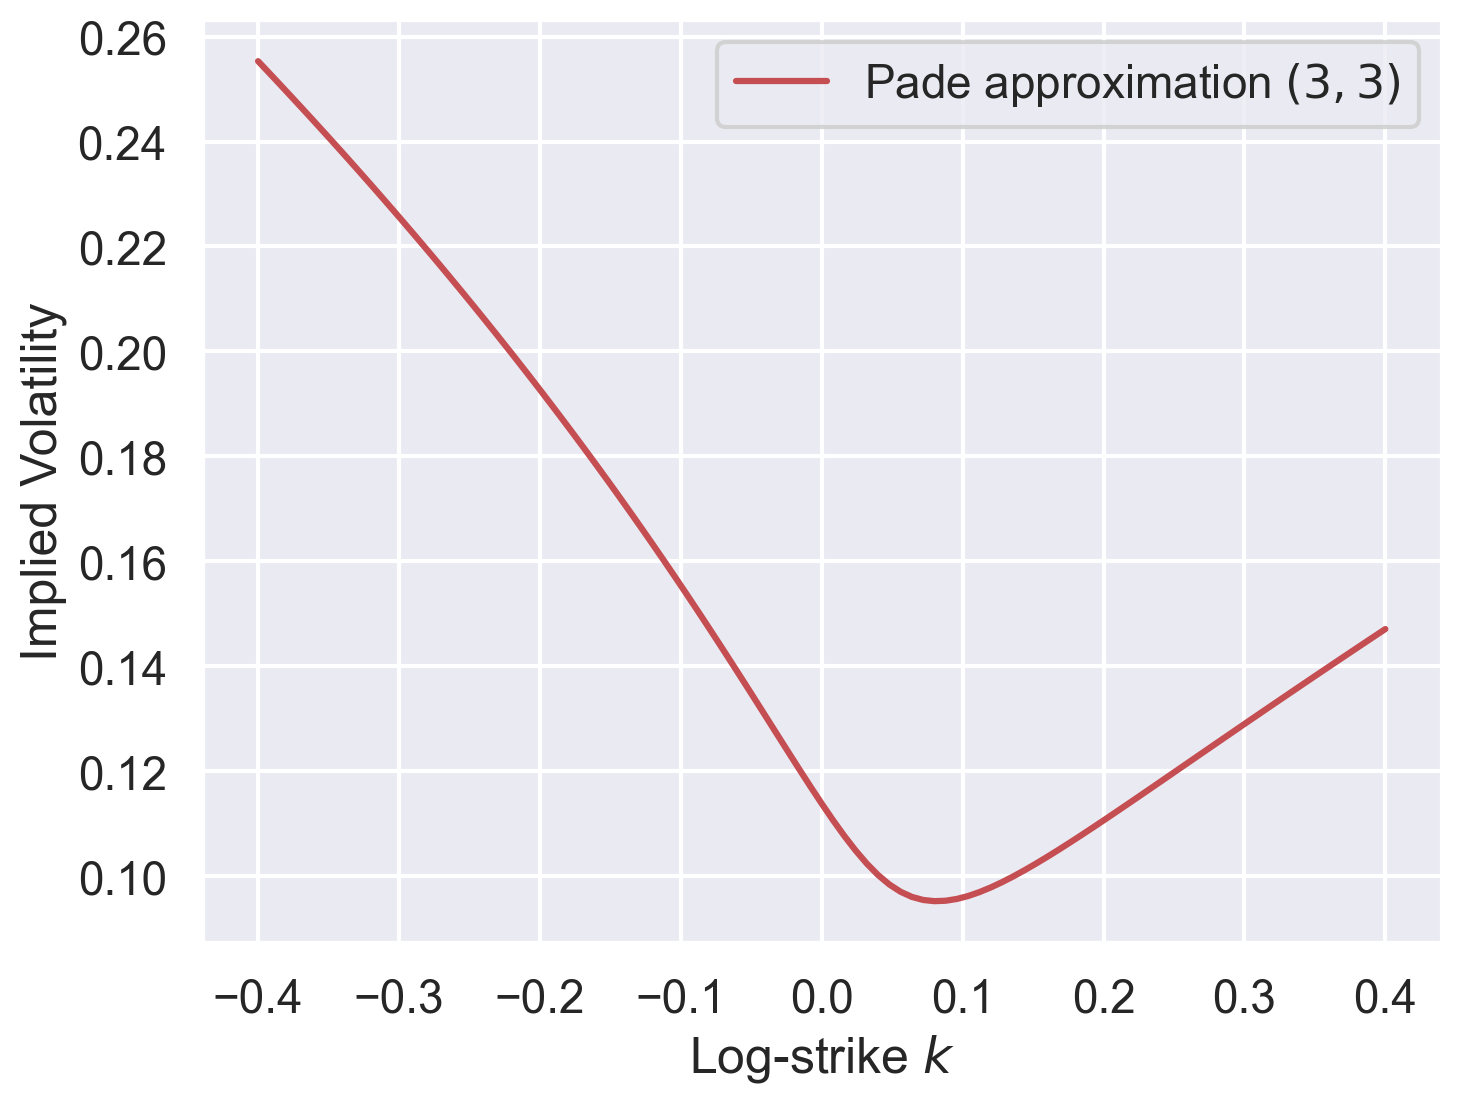

In [5]:
fig, ax = plt.subplots()
ax.plot(ks, impvols_rheston[3], "r-", label="Pade approximation $(3,3)$")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 1: The 1-year rough Heston smile using the approximation $h^{(3,3)}$.

### On generating the smile

- In our code, we compute the Lewis formula for each strike and expiration.


- There are much more efficient methods that take advantage of the structure of the characteristic fuction.
    - For example the COS method or the more recent SINC method of [Baschetti et al.]<sup id="cite_ref-BBRR" class="reference"><a href="#cite_note-BBRR">[3]</a></sup>.
        - Their code is available at https://github.com/fabioBaschetti/SINC-method!

### How does $h^{(3,3)}$  compare with $h^{(2,2)}$ and $h^{(4,4)}$ ?

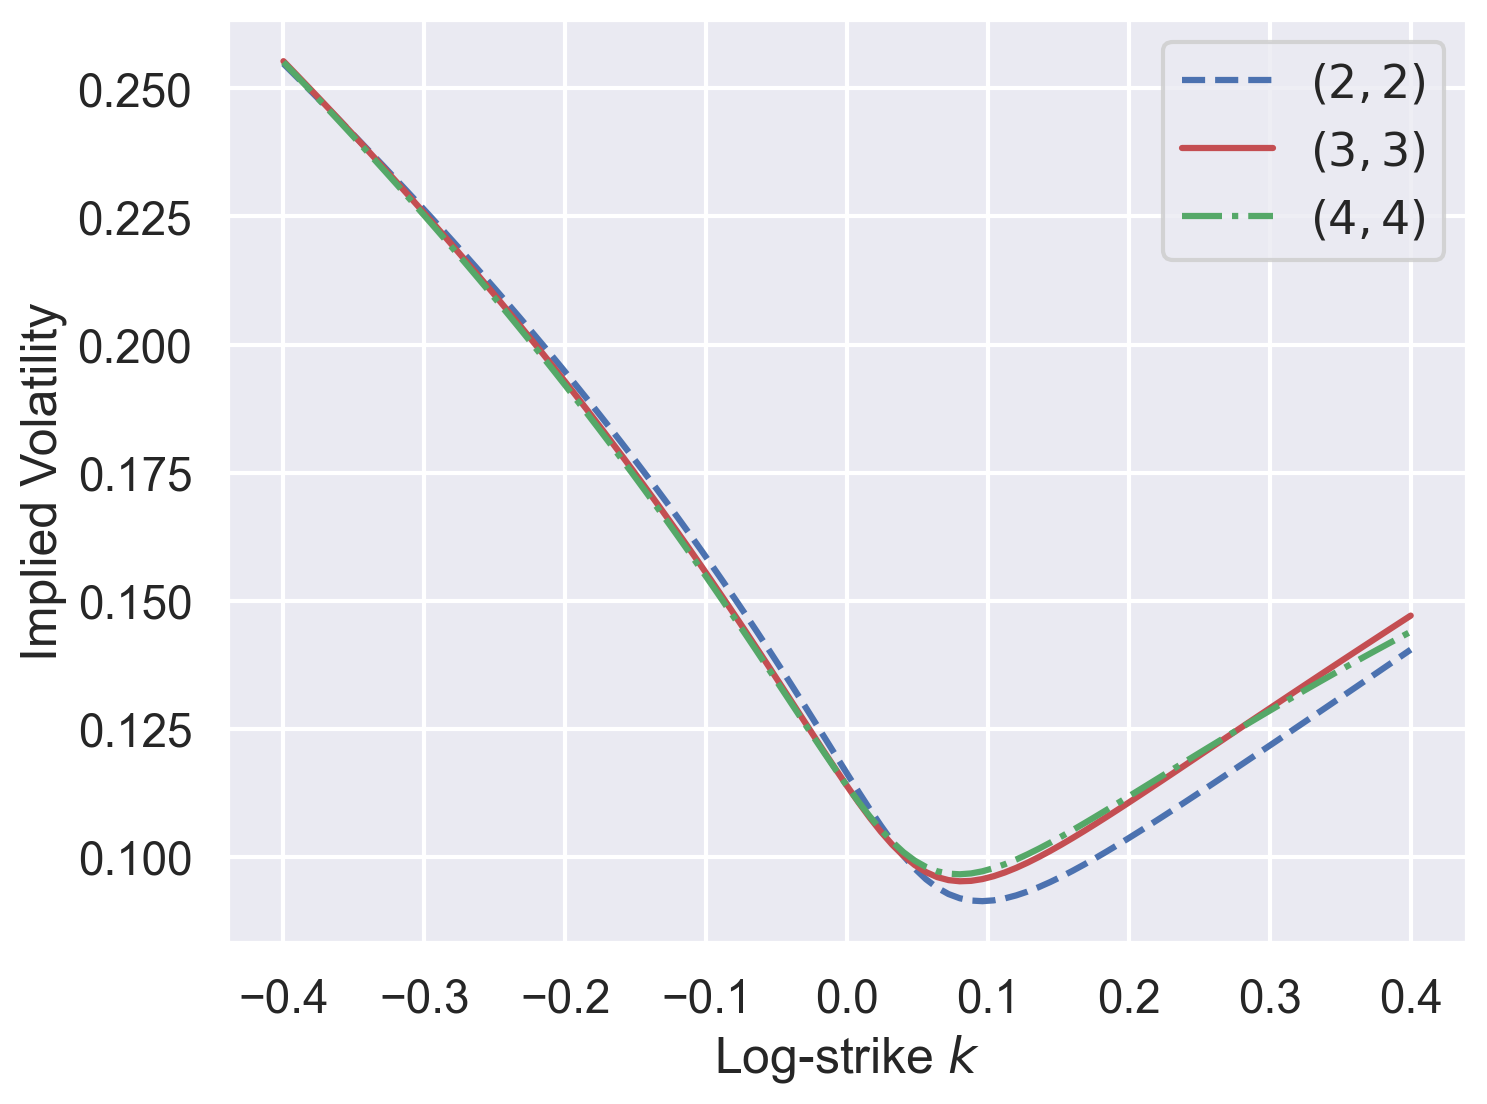

In [6]:
opt_plots = {2: "b--", 3: "r-", 4: "g-."}

fig, ax = plt.subplots()
for n_pade in list_n_pade:
    ax.plot(
        ks, impvols_rheston[n_pade], opt_plots[n_pade], label=f"$({n_pade},{n_pade})$"
    )
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 2: The 1-year rough Heston smile in red with approximation $h^{(3,3)}$.  The blue dashed line is $h^{(2,2)}$, and the green dotted line $h^{(4,4)}$.

### Sensitivity of the rough Heston smile to $\nu$

In [7]:
nu_vec = params_rheston["nu"] + np.array([0.1, 0.2, 0.3, 0.4, 0.5])
print(nu_vec)

[0.5 0.6 0.7 0.8 0.9]


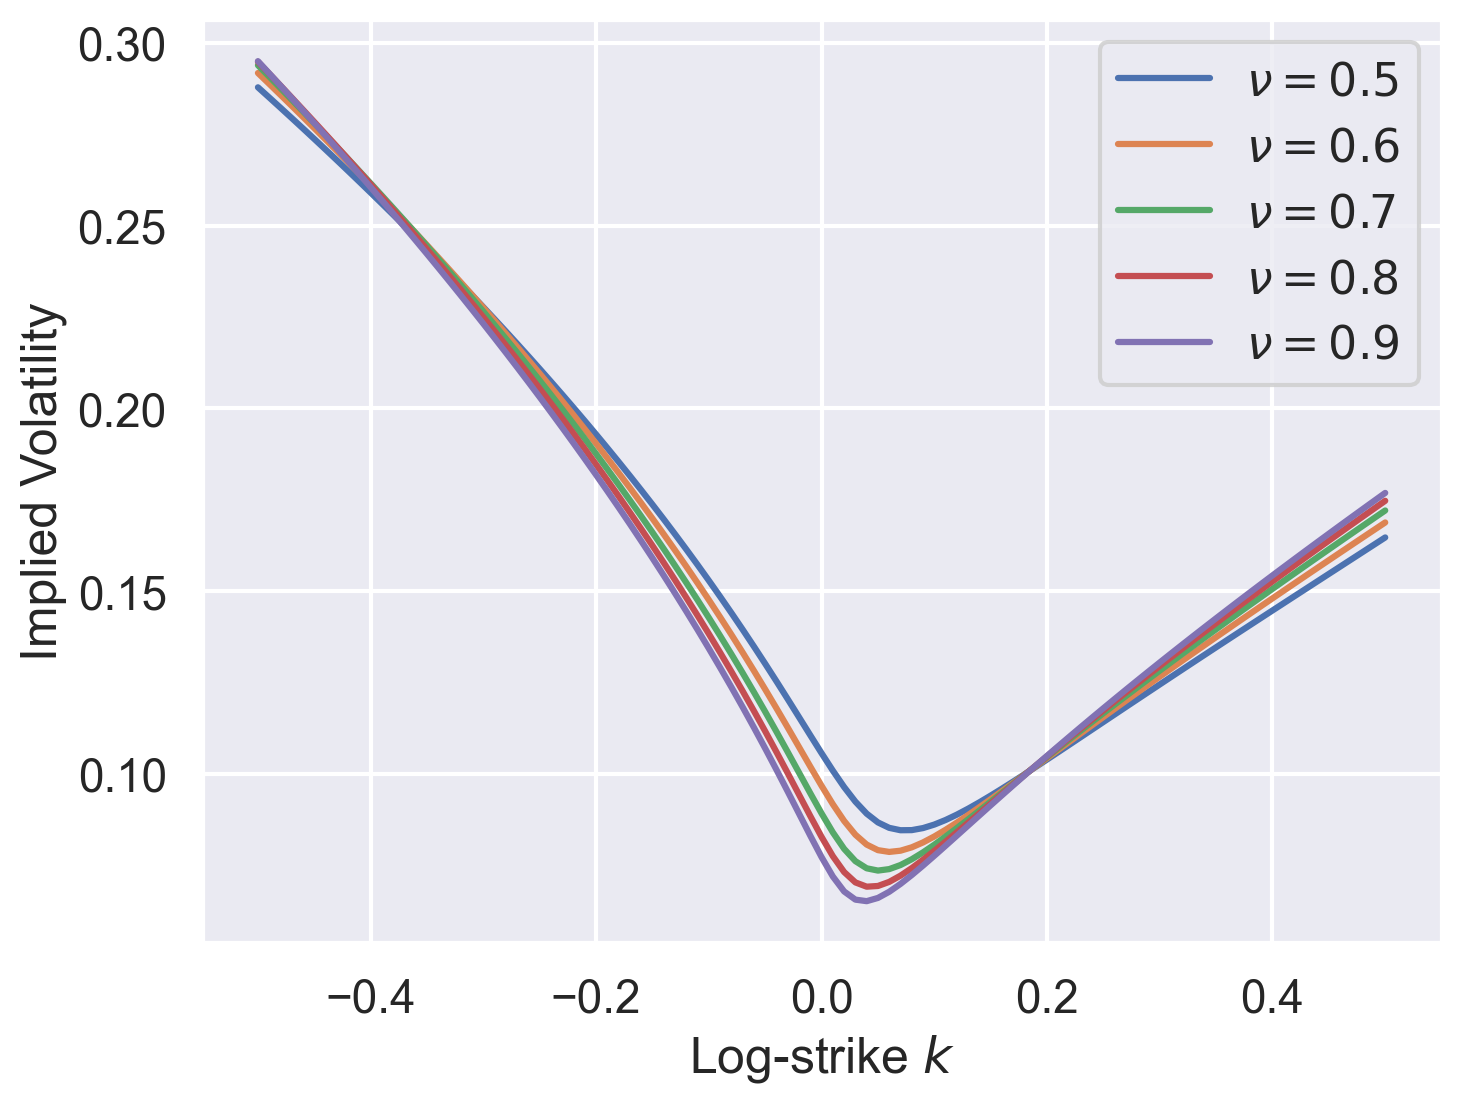

In [8]:
n_quad = 40  # Gauss quadrature points
n_pade = 2  # Choose the order of the Pade approximation
ks = np.linspace(-0.5, 0.5, 101)
tau = 1.0

fig, ax = plt.subplots()
for nu in nu_vec:
    params_rheston["nu"] = nu
    impvol_nu = impvol_rheston_rational(
        k=ks, tau=tau, params=params_rheston, xi=xi_curve, n_pade=n_pade, n_quad=n_quad
    )
    ax.plot(ks, impvol_nu, label=f"$\\nu={nu:.1f}$")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 3: The lines are smiles with $\eta \mapsto =\eta+\{0.1,0.2,0.3,0.4,0.5\}$. 

### Sensitivity of the rough Heston smile to $\rho$

In [9]:
params_rheston = {"H": 0.05, "nu": 0.4, "rho": -0.65, "lbd": 0.0}
rho_vec = params_rheston["rho"] - np.array([0.05, 0.10, 0.15, 0.20, 0.25])

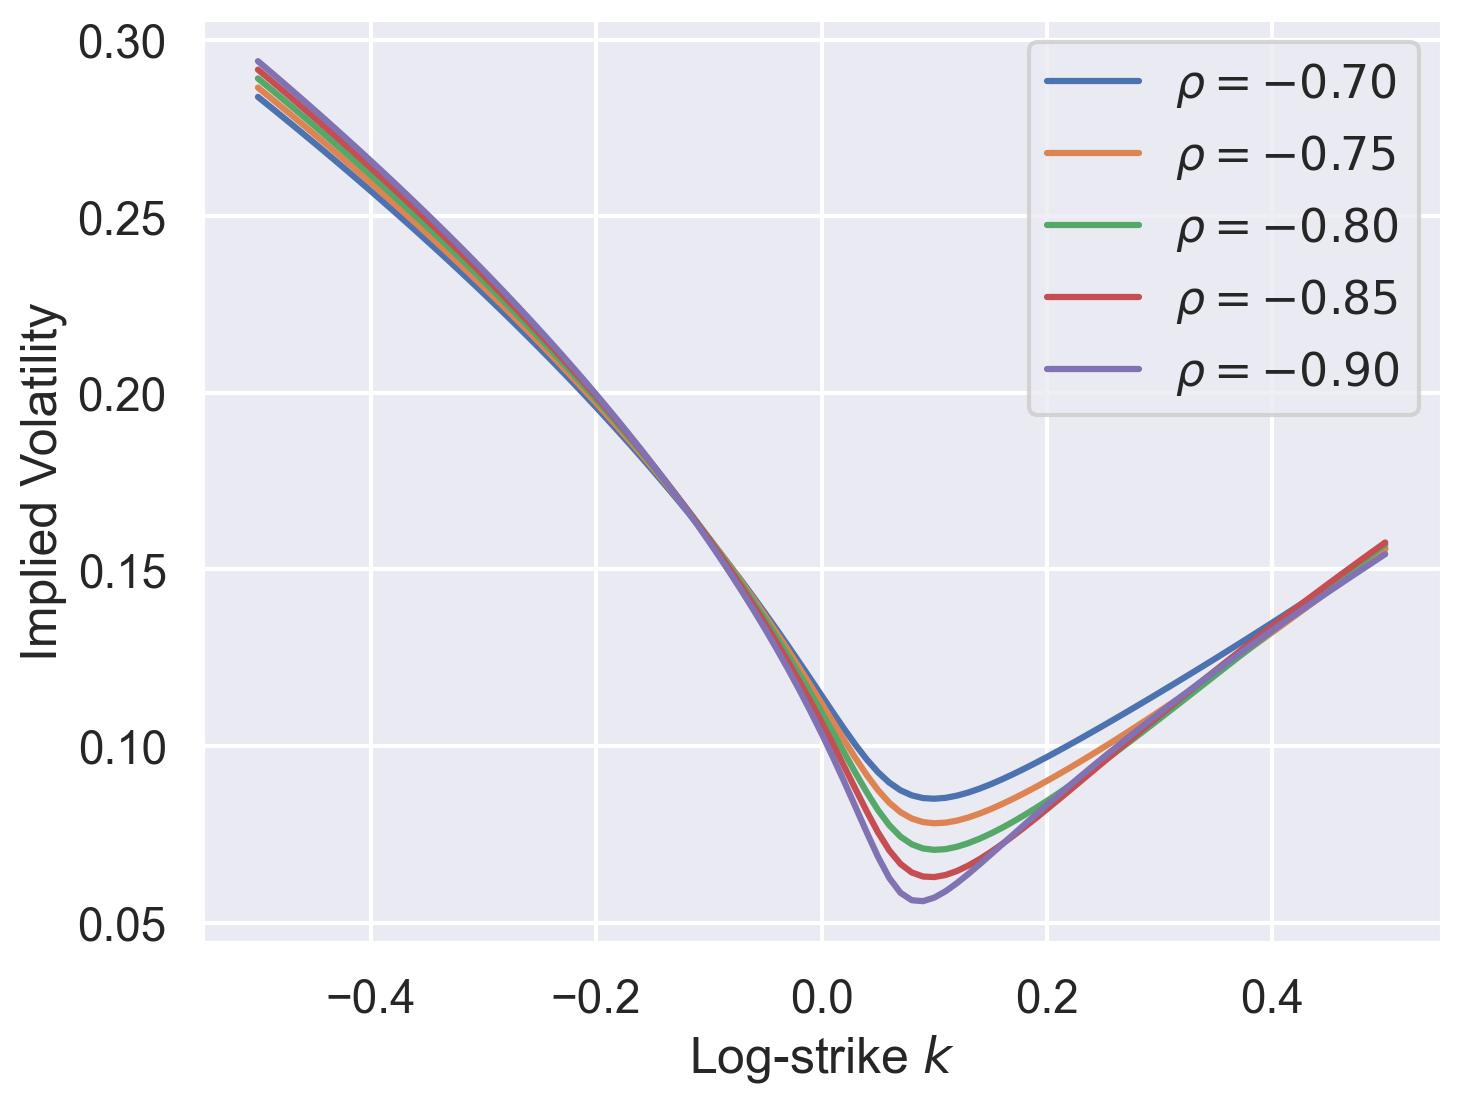

In [10]:
n_quad = 30
n_pade = 2
ks = np.linspace(-0.5, 0.5, 101)
tau = 1.0

fig, ax = plt.subplots()
for rho in rho_vec:
    params_rheston["rho"] = rho
    impvol_rho = impvol_rheston_rational(
        k=ks, tau=tau, params=params_rheston, xi=xi_curve, n_pade=n_pade, n_quad=n_quad
    )
    ax.plot(ks, impvol_rho, label=f"$\\rho={rho:.2f}$")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 4: The dotted lines are smiles with $\rho \mapsto \rho-\{0.05,0.10,0.15,0.2,0.25\}$. 

### Sensitivity of the rough Heston 1 year smile to $H$


In [11]:
params_rheston = {"H": 0.05, "nu": 0.4, "rho": -0.65, "lbd": 0.0}
H_vec = params_rheston["H"] + np.array([0.1, 0.2, 0.3, 0.4])

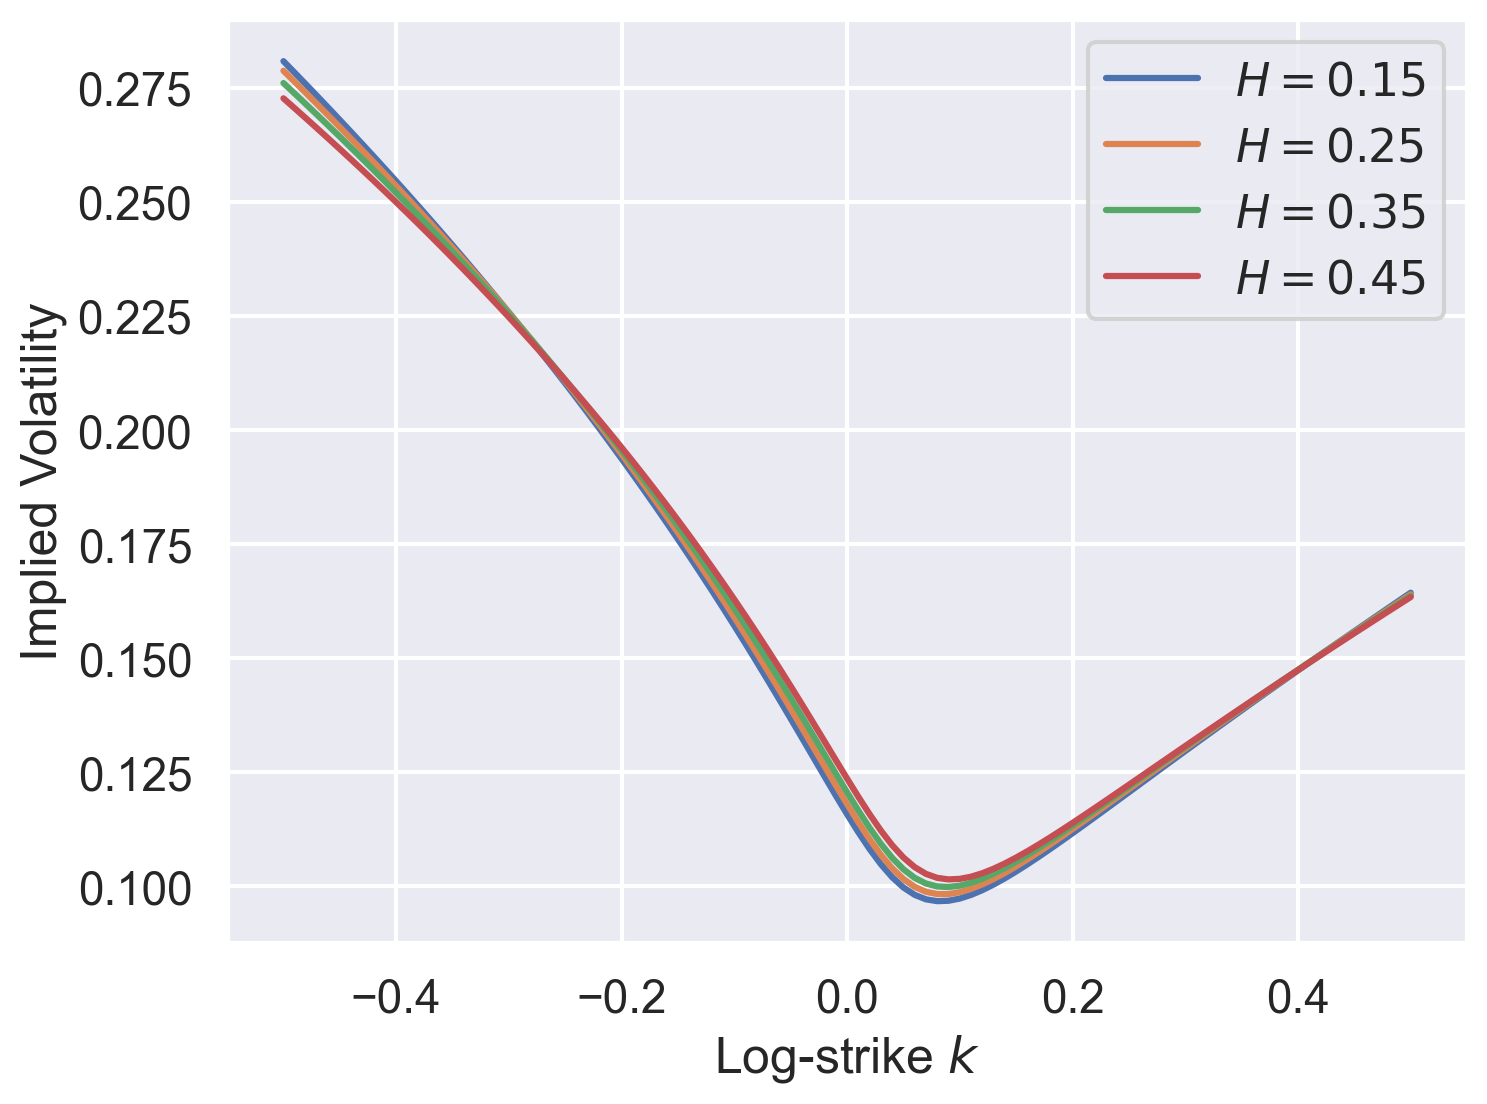

In [12]:
n_quad = 40
n_pade = 3
ks = np.linspace(-0.5, 0.5, 101)
tau = 1.0

fig, ax = plt.subplots()
for H in H_vec:
    params_rheston["H"] = H
    impvol_H = impvol_rheston_rational(
        k=ks, tau=tau, params=params_rheston, xi=xi_curve, n_pade=n_pade, n_quad=n_quad
    )
    ax.plot(ks, impvol_H, label=f"$H={H:.2f}$")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 5: The lines are 1 year smiles with $H \mapsto H +\{0.1,0.2,0.3,0.4\}$. 

### Sensitivity of the rough Heston 1 week smile to $H$


In [13]:
params_rheston = {"H": 0.05, "nu": 0.4, "rho": -0.65, "lbd": 0.0}
H_vec = params_rheston["H"] + np.array([0.1, 0.2, 0.3, 0.4])

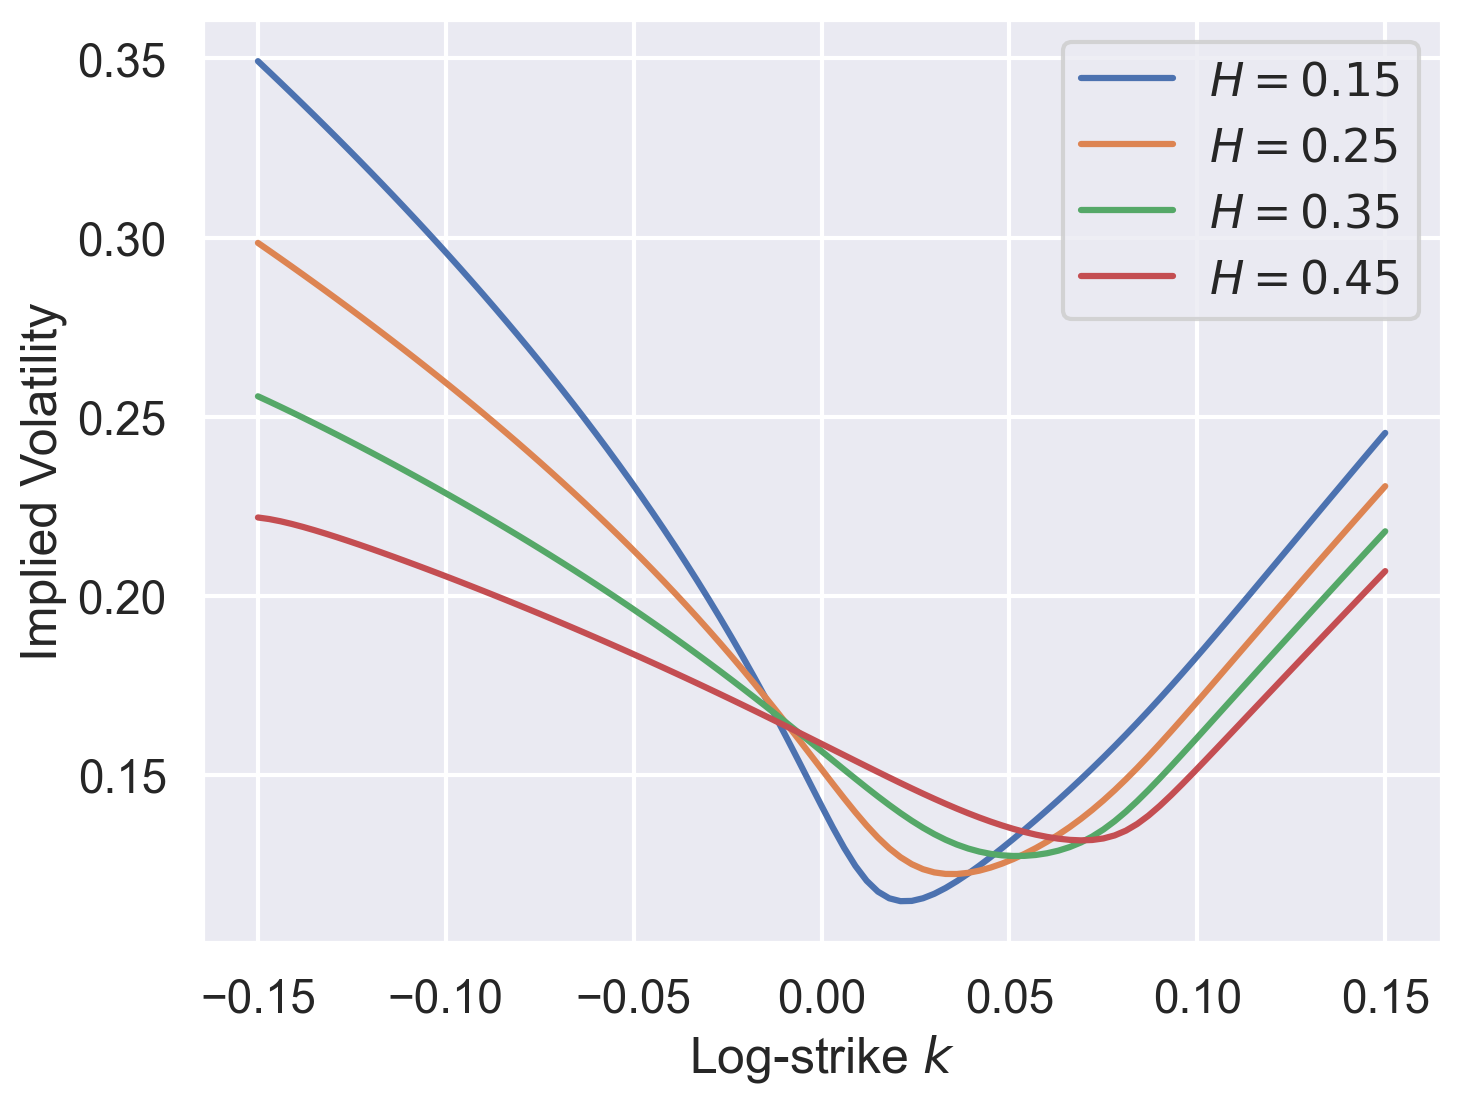

In [14]:
n_quad = 40
n_pade = 3
ks = np.linspace(-0.15, 0.15, 101)
tau = 1 / 52

fig, ax = plt.subplots()
for H in H_vec:
    params_rheston["H"] = H
    impvol_H = impvol_rheston_rational(
        k=ks, tau=tau, params=params_rheston, xi=xi_curve, n_pade=n_pade, n_quad=n_quad
    )
    ax.plot(ks, impvol_H, label=f"$H={H:.2f}$")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 6: The dotted lines are 1 week smiles with $H \mapsto H +\{0.1,0.2,0.3,0.4\}$. The smile flattens as we increase $H$.

### Ease of calibration of rough volatility models

- Rough volatility models are typically very parsimonious.


- Moreover, from the above sensitivity analyses, the effect of changing each parameter is clear:
    - $\nu$ controls curvature
    - $\rho$ controls slope/orientation
    - $H$ controls explosivity
    
    
    
- Contrast this with the classical Heston model where volatility of volatility and mean reversion are competing effects.

### Dynamics of the rough Heston volatility surface

- All rough stochastic volatility models have essentially
the same implications for the shape of the volatility surface.


- Recall from Lecture 2 that we can differentiate between models by examining how ATM skew depends on ATM volatility keeping model parameters fixed.


- In Figure 7, we see that rough Heston dynamics are not consistent with empirical dynamics, in contrast to rough Bergomi.

<h3><img src="figures/4/3m_atm_skew_vs_3m_atm_vol.png" align = "left" width=1200></h3> 

Figure 7: Blue points are empirical 3-month ATM volatilities and skews (from Jan-1996 to today); the red line is the rough Bergomi computation with the above parameters; the pink curve is the rough Heston computation.

### Fit rough Heston on February 15, 2023

- Recall that in Lecture 3, we estimated the (strange-looking) parameters:

H: 0.511599077350975

nu: 1.04560609788258

rho: -0.971373372481705

lbd: 2.23552496279593

 - Not surprisingly, these parameters generate pretty bad-looking smiles.


- However, surprisingly, fitting to just 5 points of each of the six slices in our earlier subset of smiles, we get rather similar parameters:

### Load the implied volatility data

In [15]:
df_spx = pd.read_csv("data/spx_implied_vol_20230215.csv", index_col=0)

### Load the forward variance curve

In [16]:
res_vs = var_swap_robust(ivol_data=df_spx)
expiries = res_vs["expiries"]
vs = res_vs["vs_mid"]
w_in = vs * expiries
xi_smooth = xi_curve_smooth(expiries, w_in, eps=0.03)["xi_curve"]  # function

/Users/florianbourgey/projects/jim-gatheral/RoughVolatilityWorkshop/var_gamma_swaps.py:85: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  wbar_flat = quad(PchipInterpolator(np.sort(y_in), sig_in_y**2), y_min, y_max)[0]


### Extract six slices

In [17]:
sub_expiries = df_spx["Texp"].unique()[[1, 9, 20, 27, 33, 41]]
df_spx_sub = df_spx[df_spx["Texp"].isin(sub_expiries)].dropna().reset_index(drop=True)
df_spx_sub["LogStrike"] = np.log(
    df_spx_sub["Strike"].to_numpy() / df_spx_sub["Fwd"].to_numpy()
)

In [18]:
df_spx_sub

,Expiry,Texp,Strike,Bid,Ask,Fwd,CallMid,LogStrike
0,20230217,0.005476,3555.0,0.634574,0.710785,4146.458928,591.521393,-0.153900
1,20230217,0.005476,3560.0,0.629177,0.704830,4146.458928,586.521393,-0.152494
2,20230217,0.005476,3565.0,0.623785,0.698879,4146.458928,581.521393,-0.151091
3,20230217,0.005476,3570.0,0.618398,0.692933,4146.458928,576.521393,-0.149689
4,20230217,0.005476,3575.0,0.613015,0.686992,4146.458928,571.521393,-0.148290
...,...,...,...,...,...,...,...,...
1079,20240216,1.002053,6200.0,0.143303,0.147932,4307.892520,1.527051,0.364100
1080,20240216,1.002053,6400.0,0.146009,0.153408,4307.892520,1.026810,0.395849
1081,20240216,1.002053,6600.0,0.148471,0.158850,4307.892520,0.710868,0.426621
1082,20240216,1.002053,6800.0,0.152086,0.164383,4307.892520,0.526569,0.456474


### Compute `modelVol`

In [19]:
n_pade = 2
n_quad = 30
fit_5 = {"H": 0.53, "rho": -0.64, "nu": 1.11, "lbd": 1.28}
impvols_rheston = {}

for expiry in sub_expiries:
    print(f"expiry: {expiry:<.4}")
    df_expiry = df_spx_sub[df_spx_sub["Texp"] == expiry]
    ks = df_expiry["LogStrike"].to_numpy()
    impvols_rheston[expiry] = impvol_rheston_rational(
        k=ks,
        tau=expiry,
        params=fit_5,
        xi=xi_smooth,
        n_pade=n_pade,
        n_quad=n_quad,
    )

expiry: 0.005476
Implied volatility did not converge for all log(K/F) values.
expiry: 0.04107
Implied volatility did not converge for all log(K/F) values.
expiry: 0.08214
Implied volatility did not converge for all log(K/F) values.
expiry: 0.2546
expiry: 0.5038
expiry: 1.002


### Plot the smiles

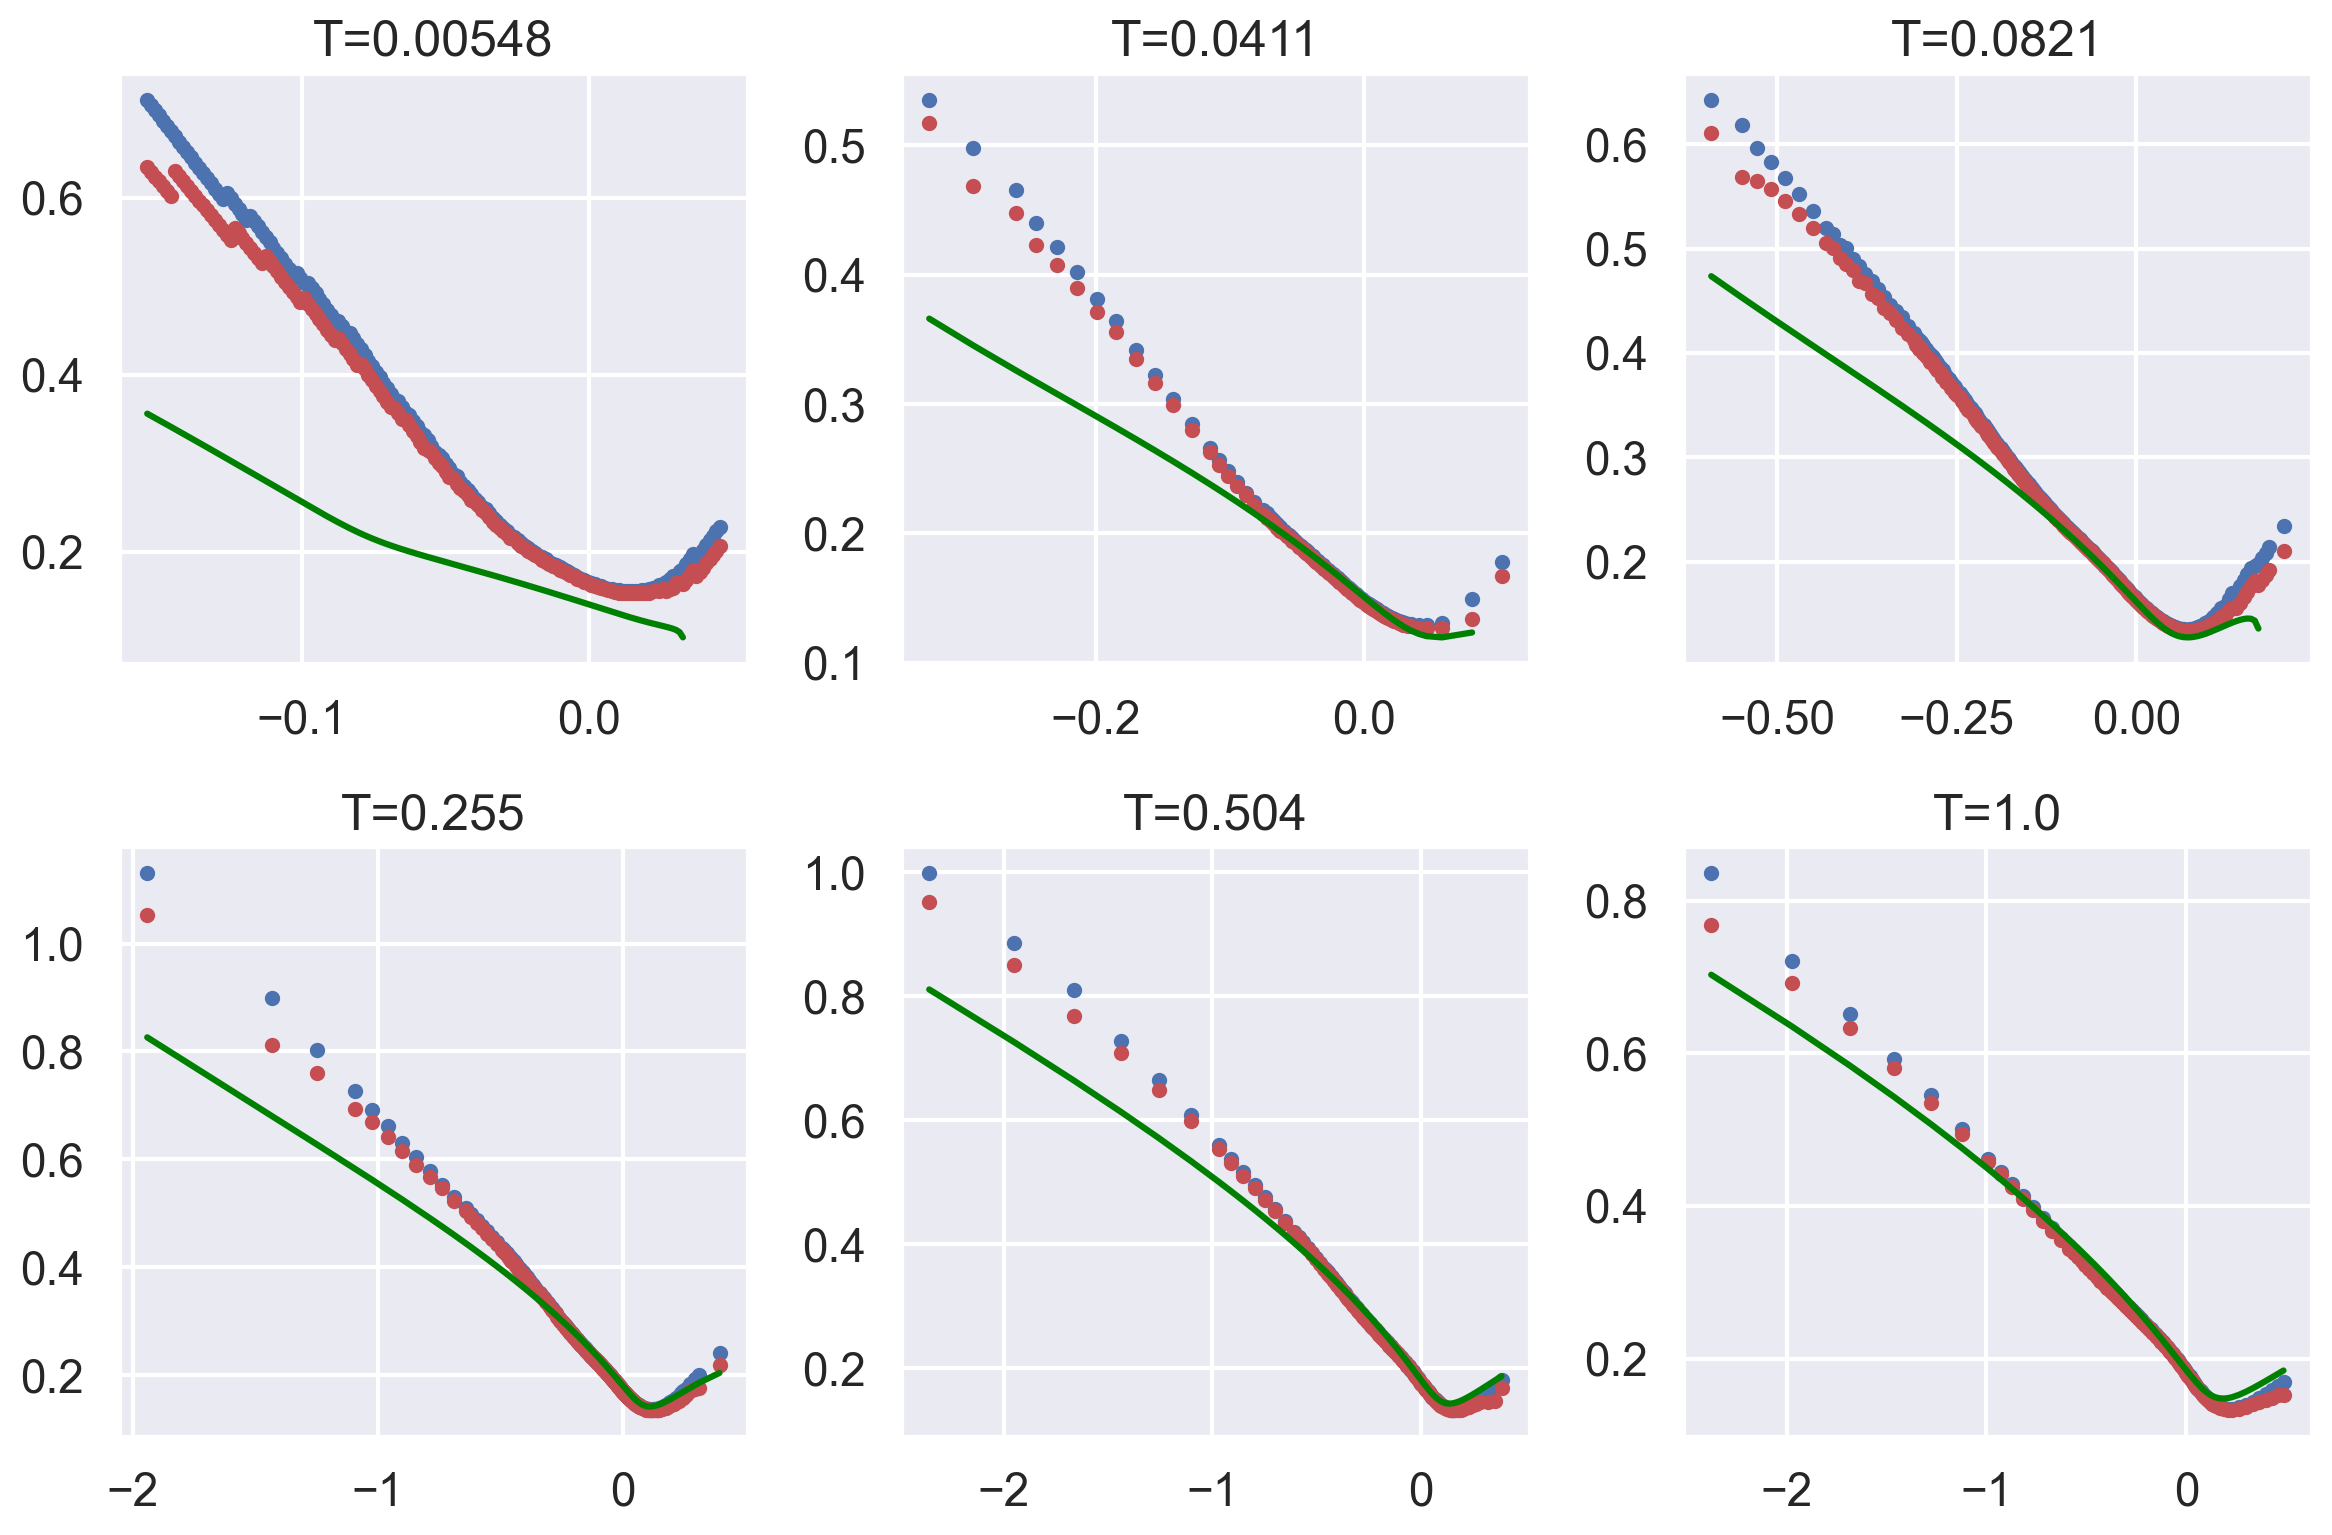

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i, expiry in enumerate(sub_expiries):
    df_expiry = df_spx_sub[df_spx_sub["Texp"] == expiry]
    ks = df_expiry["LogStrike"]
    ask = df_expiry["Ask"]
    bid = df_expiry["Bid"]
    ax_i = ax[i // 3, i % 3]
    ax_i.plot(ks, ask, "b.")
    ax_i.plot(ks, bid, "r.")
    ax_i.plot(ks, impvols_rheston[expiry], color="green")
    ax_i.set_title(f"T={expiry:<.3}")
plt.tight_layout()
plt.show()

Figure 8: Six rough Heston smiles (green) with `fit.5` parameters superimposed on February 15, 2023 SPX smiles.

### Comments on Figure 8



- With just one computation for 6 slices taking 70 seconds, calibration with this code is not practical.
    - We would need, at the least, to use something like the SINC method of [Baschetti et al.]<sup id="cite_ref-BBRR" class="reference"><a href="#cite_note-BBRR">[3]</a></sup>.
    
    
- The parameters look crazy - very close to classical Heston.
    - And inconsistent with the scaling of VIX futures seen in Lecture 2.
    - But at least they are consistent with the leverage contract estimates of Lecture 3.

- With just one computation for 6 slices taking 60 seconds, calibration with this code is not practical.

### Why Monte Carlo?

- The rational approximation allows us to value European options only.


- We may be (are) interested in valuing other kinds of option.
    We need a Monte Carlo scheme.
    
    
  - Also, we  have a rational approximation for rough Heston only.
      - The Monte Carlo scheme can have any kernel.

### Andersen's Quadratic Exponential (QE) scheme

- [Andersen]<sup id="cite_ref-Andersen" class="reference"><a href="#cite_note-Andersen"><span>[</span>1<span>]</span></a></sup> came up with the following clever scheme for simulating the Heston model that guarantees non-negativity of the simulated $V$ process while matching mean and variance at each step.



- Define

$$
\psi = \frac{\mathrm{var}_t[V_\Delta]}{\mathbb{E}[V_\Delta]^2}.
$$

    
    
- Expectation and variance are wrt $\mathcal{F}_t$.

### Algorithm $\psi^-$

- If $\psi \leq 2$, simulate $V_\Delta$ as

    $$
    V_\Delta = \alpha\,\left(\beta+ Z\right)^2
    $$

    with $Z \sim N(0,1)$ and 

    $$
    \begin{align*}
    \beta^2 =\frac{2}{\psi} -1+ \sqrt{\frac{2}{\psi}}\,\sqrt{\frac{2}{\psi}-1} ;\quad
    \alpha = \frac{\mathbb{E}[V_\Delta]}{1+\beta^2}.
    \end{align*}
    $$

### Algorithm $\psi^+$

- On the other hand, if $\psi \geq 1$, simulate $v_\Delta$ as

    $$
    v_\Delta = -\mathbb{1}_{U < p}\,{\gamma}\,\log \frac{U}{p}
    $$

    with $U_n \sim \mathcal{U}(0,1)$ and

    $$
    \begin{align*}
    p =\frac{2}{1+\psi};\quad
    \gamma = \frac{1}{2}\,\mathbb{E}[v_\Delta]\,\left(1+\psi\right) .
    \end{align*}
    $$

- It is straightforward to check that means and variances are correctly matched in both cases.
    - The quadratic and exponential distributions are chosen because they have similar shapes to the true distribution in their respective regions of applicability.


- Since the two regions of applicability overlap, Andersen suggests to use algorithm $\psi^-$ if $\psi<3/2$ and algorithm $\psi^+$ if $\psi \geq 3/2$.


- Note that the algorithms $\psi^\pm$ depend only on expectation and variance so this scheme should work whenever these can be computed or approximated.
    - In particular in the case of affine forward variance models.

### Affine forward variance (AFV) models
    
- Now, followng [Efficient Simulation]<sup id="cite_ref-Efficient" class="reference"><a href="#cite_note-Efficient"><span>[</span>5<span>]</span></a></sup>, we explain how to simulate affine forward variance (AFV) models in general.
    - In particular, rough affine models.
    
    
 - In order to do this, we extend Andersen's QE scheme to get the mean and variance correct at each step.
 
 
 - And we adapt the hybrid scheme of [Bennedsen et al.]<sup id="cite_ref-Hybrid" class="reference"><a href="#cite_note-Hybrid">[2]</a></sup>.

### Discretization of the spot and variance processes

From the AFV dynamics,
$$
d\xi_t(u) = \kappa(u-t)\,\sqrt{V_t}\, dW_t,
$$
it follows that
 
$$
\begin{align*}
    V_T = \xi_T(T)  &= \xi_0(T) +\int_0^T\,d\xi_s(T)\nonumber\\
    &= \xi_0(T) +\int_0^T\,\kappa(T-s)\,\sqrt{V_s}\,dW_s.
\end{align*}
$$

### Formal representation of the $V$ process

- Wlog, let $t=0$ and  $\xi(u)=\xi_0(u)$. Let the time step $\Delta = T/n$ where $n$ is the number of steps.  






-  As in [Bennedsen et al.]<sup id="cite_ref-Hybrid" class="reference"><a href="#cite_note-Hybrid">[2]</a></sup>, we have the following exact decomposition:
<br>
<br>
$$
V_{n \Delta} =\xi(n \Delta) + \sum_{k=1}^{n}\,\int^{k \Delta}_{(k-1)\Delta}\,\kappa( n\Delta - s)\,\sqrt{V_s}\,dW_s.
$$

### Discretization of the $V$ process

- With simpler notation,

    $$
    V_n =\xi_n  + \sum_{k=1}^{n}\,\int^{k \Delta}_{(k-1)\Delta}\,\kappa( n\Delta - s)\,\sqrt{V_s}\,dW_s
    =: \hat \xi_n  + u_n,
    $$
    where the $\mathcal{F}_{n-1}$-adapted variable $\hat \xi_n$ is given by

    $$
    \hat \xi_n := \mathbb{E}[V_n | \mathcal{F}_{n-1}] = \xi_n  + \sum_{k=1}^{n-1}\,\int^{k \Delta}_{(k-1)\Delta}\,\kappa( n\Delta - s)\,\sqrt{V_s}\,dW_s,
    $$

    and the martingale increment $u_n$ by

    $$
    u_{n} := \int_{(n-1) \Delta }^{n \Delta}\,\kappa(n \Delta-s)\,\sqrt{V_s}\,dW_s.
    $$

### The $X$ process

- We also need to simulate the $n$-th increment of the component of the log-stock price process $X =\log S$ parallel to the volatility process:

$$
\chi_n  = \int_{(n-1) \Delta }^{n \Delta}\,\sqrt{V_s}\,dW_s.
$$

- We write the increments as $\chi_n$ to emphasize that they should be approximately $\chi^2$-distributed random variables.

- We then have the following discretization of the $X$ process:

$$
X_n 
= 
X_{n-1}-\tfrac14\,(V_n+V_{n-1})\,\Delta
+
\sqrt{1-\rho^2}\,\sqrt{\bar V_n\,\Delta}\,Z^\perp_n+\rho\,\chi_n,
$$

where $Z_n^\perp$ is standard normal, independent of $\chi_n$ and $u_n$.

### Choices of kernel

Let $\tilde \eta = \eta\,\sqrt{2 H}$. The code uses the gamma kernel $\kappa(\tau) = \tilde \eta\, \tau^{\alpha-1}\, e^{-\lambda \tau}$ which has the two special cases
  - The *power-law* kernel (rough Heston with $\lambda=0$)
    <p>
$$
\kappa(\tau)= \sqrt{2 H}\,\eta\, \tau^{\alpha-1}=: \tilde \eta\, \tau^{\alpha-1},
$$

  - and the exponential kernel (classical Heaton)
$$
\kappa(\tau)= \tilde \eta\, e^{-\lambda \tau}.
$$  

- The algorithm can deal with any kernel however.

### Some definitions

- We define for $i,j \geq 0$,

$$
\begin{align*}
\mathcal{K}_{i}(\Delta) &= \int_0^\Delta\,\kappa(s+i\Delta)\,ds,
\\ 
\mathcal{K}_{i,j}(\Delta) &= \int_0^\Delta\,\kappa(s+i\Delta)\,\kappa(s+j\Delta)\,ds.
\end{align*}
$$


- The $\mathcal{K}_{i,j}(\Delta)$ with $i \neq j$ are not in general computable in closed-form but are easy to compute numerically.

### Covariances and correlations

- It can be shown that
$$
\mathrm{var}[u_n|\mathcal{F}_{n-1}] =\bar V_{n}\,\mathcal{K}_{0,0}(\Delta)+\mathcal{O}\left(\Delta^{1+2H}\right),
$$
where
$$
\bar V_{n} := \frac{1}{2 H + 1}\, \left[\hat \xi_n +  2 H\,V_{n-1}\right].
$$


- Similarly

$$
\begin{align*}
\mathrm{var}[\tilde \xi_{n+1}|\mathcal{F}_{n-1}] &\approx &  \bar V_{n}\,\mathcal{K}_{1,1}(\Delta)\\
\mathrm{var}[\chi_n|\mathcal{F}_{n-1}] &\approx & \bar V_{n}\,\Delta\\
\mathrm{cov}[u_n,\tilde \xi_{n+1}|\mathcal{F}_{n-1}] &\approx &  \bar V_{n}\,\mathcal{K}_{0,1}(\Delta)\\
\mathrm{cov}[u_n,\chi_n|\mathcal{F}_{n-1}]&\approx &\bar V_{n}\,\mathcal{K}_{0}(\Delta)\\
\mathrm{cov}[\chi_n,\tilde \xi_{n+1}|\mathcal{F}cF_{n-1}] &\approx &  \bar V_{n}\,\mathcal{K}_{1}(\Delta).
\end{align*}
$$

Given a suitable kernel, all of these may be easily computed.

### The correlation matrix

- Because variances and covariances in an AFV model are linear in $\xi$, the correlation matrix takes the simple form.

$$
\begin{align*}
R =   \left(\begin{array}{ccc}
    1 & \rho_{u\chi}  & \rho_{u\xi}\\ 
  \rho_{u\chi}& 1 &\rho_{\xi \chi} \\ 
 \rho_{u\xi} & \rho_{\xi \chi} & 1 \\ 
  \end{array}\right).
\end{align*}
$$
where
$$
\begin{align*}
\rho_{u\chi} &=& \frac{\mathcal{K}_{0}(\Delta)}{\sqrt{\Delta}\sqrt{\mathcal{K}_{0,0}(\Delta)}}\\
\rho_{u\xi} &=& \frac{\mathcal{K}_{0,1}(\Delta)}{\sqrt{\mathcal{K}_{0,0}(\Delta)}\sqrt{\mathcal{K}_{1,1}(\Delta)}}\\
\rho_{\xi \chi} &=& \frac{\mathcal{K}_{1}(\Delta)}{\sqrt{\Delta}\sqrt{\mathcal{K}_{1,1}(\Delta)}}
\end{align*}
$$
are all independent of $n$.

### The power-law kernel

- In the case of the power-law kernel $\kappa(\tau)= \tilde \eta\, \tau^{\alpha-1}$, these correlations are functions of $H$ only.


- Specifically
$$
\rho_{u\chi} = \frac{\sqrt{2 H}}{H+1/2},
$$
and the other correlations may be easily computed numerically.



-  In Figure 9, we plot these correlations as a function of $H$.  


### Plot of the correlation matrix in the power-law kernel case

In [21]:
params_rheston = {"H": 0.05, "nu": 0.8, "rho": -0.65, "lbd": 1e-20}

In [22]:
delta = 1 / 10
Hs = np.linspace(1e-3, 0.5, 101)
rho_u_chi_H = np.zeros_like(Hs)
rho_u_xi_H = np.zeros_like(Hs)
rho_xi_chi_H = np.zeros_like(Hs)

for i, H in enumerate(Hs):
    params_rheston["H"] = H
    rho_u_chi_H[i] = rough_heston.rho_u_chi(delta, params_rheston)[0]
    rho_u_xi_H[i] = rough_heston.rho_u_xi(delta, params_rheston)[0]
    rho_xi_chi_H[i] = rough_heston.rho_xi_chi(delta, params_rheston)[0]

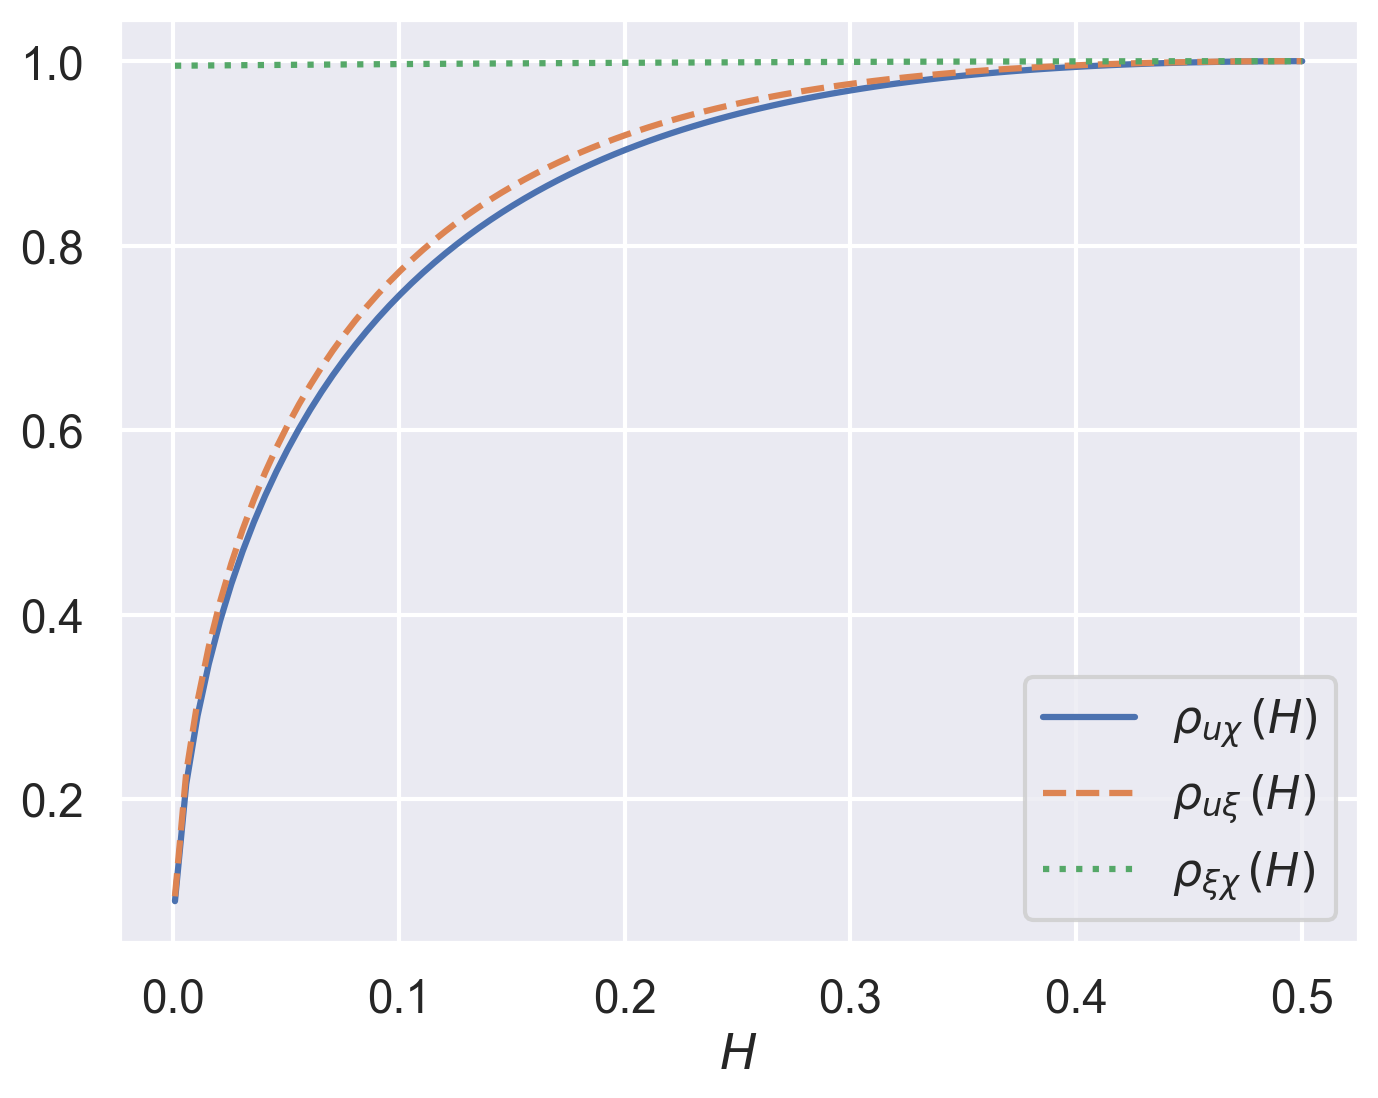

In [23]:
fig, ax = plt.subplots()
ax.plot(Hs, rho_u_chi_H, "-", label=r"$\rho_{u\chi}\,(H)$")
ax.plot(Hs, rho_u_xi_H, "--", label=r"$\rho_{u\xi}\,(H)$")
ax.plot(Hs, rho_xi_chi_H, ":", label=r"$\rho_{\xi\chi}\,(H)$")
ax.set_xlabel(r"$H$")
ax.legend()
plt.show()

Figure 9: The correlations $\rho_{u\chi}$, $\rho_{u\xi}$, and $\rho_{\xi \chi}$  vs. $H$ in the power-law kernel case.

### A further approximation

- By assumption, the kernel behaves as a power-law kernel for $\Delta$ sufficiently small.  


- Figure 9 thus suggests the following approximation whose motivation is easy to see by thinking of $\mathcal{K}_i(\Delta)$ as $\Delta$ times the average value of $\kappa(s+i\Delta)$ over the interval $(0,\Delta]$.

For $i \geq 0$ and $j \geq 1$,
$$
\mathcal{K}_{i,j}(\Delta) \,\Delta \approx \mathcal{K}_{i}(\Delta)\,\mathcal{K}_{j}(\Delta).
$$


### An approximate correlation matrix

With this last approximation,

$$
\begin{align*}
\mathcal{K}_{0,1}(\Delta) \approx \frac1\Delta \,\mathcal{K}_{1}(\Delta)\,\mathcal{K}_{0}(\Delta);\quad 
\mathcal{K}_{1,1}(\Delta) \approx \frac1\Delta \,\mathcal{K}_{1}(\Delta)^2.
\end{align*}
$$

Substituting these expressions into our earlier expression for the correlation matrix gives 

$$
\begin{align*}
\bar R =   \left(\begin{array}{ccc}
    1 & \bar \rho &\bar \rho \\ 
\bar \rho & 1 &1 \\ 
  \bar \rho & 1 & 1 \\ 
  \end{array}\right),
\end{align*}
$$

where
$$
\bar \rho 
\approx \frac{\mathcal{K}_0(\Delta)}{\sqrt{\mathcal{K}_{0,0}(\Delta)\,\Delta}} = \rho_{u \chi}.
$$


### Consequences for simulation

- At each step, we need to generate (at least) three random variables: $u_n$, $\chi_n$, and $\hat \xi_{n+1}$. 

$$
\begin{align*}
u_{n} &=  \int_{(n-1) \Delta }^{n \Delta}\,\kappa(n \Delta-s)\,\sqrt{V_s}\,dW_s,\\
\chi_n  &= \int_{(n-1) \Delta }^{n \Delta}\,\sqrt{V_s}\,dW_s,\\
\hat \xi_{n+1} &=
 \xi_{n+1}  + \sum_{k=1}^{n}\,\int^{k \Delta}_{(k-1)\Delta}\,\kappa( (n+1)\Delta - s)\,\sqrt{V_s}\,dW_s.
\end{align*}
$$

- When the model is Markovian ($H=1/2$), we need only generate $u_n$ at the $n$-th timestep; $\chi_n$ and $\hat \xi_{n+1}$ are perfectly correlated with $u_n$. 

    - In practice, in the non-Markovian case ($H<1/2$),  we need only generate one other random variable consistent with the correlation matrix $\bar R$.

### Average values of the kernel

- Echoing the notation of [Bennedsen et al.]<sup id="cite_ref-Hybrid" class="reference"><a href="#cite_note-Hybrid">[3]</a></sup>, let
$$
 {b^\star_j}^2 = \frac 1 \Delta\, \mathcal{K}_{j-1,j-1}(\Delta).
$$

- $ {b^\star_j}^2$ thus gives the RMS average of the kernel at the $j$-th lag.

### The evolution of the forward variance curve

- The approximation
$$
\begin{align*}
\int^{k \Delta}_{(k-1)\Delta}\,\kappa( (n+1)\Delta - s)\,\sqrt{V_s}\,dW_s
&\approx& b^\star_{n+1-k}\,\chi_k
\end{align*}
$$
gives
$$
\begin{align*}
\hat \xi_{n+1} &\approx&
 \xi_{n+1}  + \sum_{k=1}^{n}\,b^\star_{n+1-k}\,\chi_k.
\end{align*}
$$


- Similarly (though not needed for the algorithm), for $m>n$,
$$
\begin{align*}
\mathbb{E}[V_m | \mathcal{F}_n] &\approx&
 \xi_{m}  + \sum_{k=1}^{n}\,b^\star_{m-k}\,\,\chi_k.
\end{align*}
$$

- We see that the entire forward variance curve evolves according to the weighted historical path of the $X = \log  S$ process.


### A Riemann-sum QE scheme

- Inspired by the Riemann-sum scheme of [Bennedsen et al.]<sup id="cite_ref-Hybrid" class="reference"><a href="#cite_note-Hybrid">[2]</a></sup> and the rough-Donsker scheme of [Horvath et al.]<sup id="cite_ref-Donsker" class="reference"><a href="#cite_note-Donsker">[8]</a></sup>, we simulate the $u_{n}$, $\hat \xi_{n+1}$ and $\chi_n$ as if all three were perfectly correlated, equivalent to setting $\bar \rho =1$ in [(7)](#eq:rhoMatrix). 


- From Figure 9 such an approximation may be justified if $H$ is not too much less than $\tfrac12 $.

### The RSQE scheme


1. Given $\chi_k$, for $k <n$, with $\epsilon$ very small, compute $ \hat \xi_{n} =\max\left[ \epsilon, \, \xi_{n} +  \sum_{k=1}^{n-1}\,b^\star_{n-k+1}\,\chi_k \right]$.

2. With 
$\mathrm{var}[V_n|\mathcal{F}_{n-1}] 
= {b_1^\star}^2\,\bar V_n\,\Delta$, 
simulate $V_n$ using the QE scheme.

3. $u_n= V_n - \hat \xi_n$.

4. $\hat\xi_{n+1}=\xi_{n+1}+\sum_{k=1}^n\,\frac{b_{n-k+1}^\star}{b_1^\star}\,u_k$.

5. Finally, $
X_n = X_{n-1}-\tfrac14\,(V_n+V_{n-1})\,\Delta+\sqrt{1-\rho^2}\,\sqrt{\bar V_n\,\Delta}\,Z^\perp_n
+\rho\,\chi_n$.

### Classical Heston with RSQE

- Classical Heston has $H=\tfrac12$ and the exponential kernel is a special case of the gamma kernel.
    - Let's apply the RSQE code to the classical Heston case.

In [24]:
params_heston = {
    "H": 0.5,  # H=0.5 for classical Heston
    "nu": 0.8,  # volatility of volatility parameter
    "rho": -0.65,  # correlation parameter
    "lbd": 1.0,  # mean reversion rate
    "vbar": 0.04,  # long-term variance
    "v": 0.04,  # initial variance
}


# Define forward variance curve function
def xi_curve(t):
    return 0.04 + 0 * t


T = 1.0
ks = np.linspace(-0.8, 0.4, 101)

### Run the RSQE Monte Carlo

In [25]:
n_mc = 1 * 10**5
n_steps = 200
seed = 12345

In [26]:
res_rsqe = rough_heston.simulate_rsqe(
    T=T, params=params_heston, xi=xi_curve, n_mc=n_mc, n_steps=n_steps, seed=seed
)

/Users/florianbourgey/projects/jim-gatheral/RoughVolatilityWorkshop/heston.py:38: RuntimeWarning: invalid value encountered in sqrt
  beta2 = 2 / psi - 1 + np.sqrt(2 / psi) * np.sqrt(2 / psi - 1)


In [27]:
impvol_heston_rsqe = black_otm_impvol_mc(S=np.exp(res_rsqe["x"]), k=ks, T=T)

### Why is RSQE slow compared to Andersen's QE scheme?

- The reason is the convolution step
$ \hat \xi_{n} =\max\left[ \epsilon, \, \xi_{n} +  \sum_{k=1}^{n-1}\,b^\star_{n-k+1}\,\chi_k \right]$.


- In the case of the exponential kernel,
$$
 {b^\star_j}^2 = \frac 1 \Delta\, \mathcal{K}_{j-1,j-1}(\Delta) = \eta^2\,\frac 1 \Delta\, \int_{(j-1)\Delta}^{j \Delta}\,e^{-2\lambda s}\,ds = e^{-2(j-1)\Delta}\,{b^\star_1}^2.
$$
so rather than compute the convolution at each step, we need only keep track of the exponentially weighted moving average of the $\chi_j$.
     - That would save a lot of time!
     
     
- If the kernel is not exponential, we are out of luck.



### Compare RSQE with exact classical Heston smile

In [28]:
impvol_heston = impvol_heston_charfunc(ks, T, params_heston)

### Plot the smiles

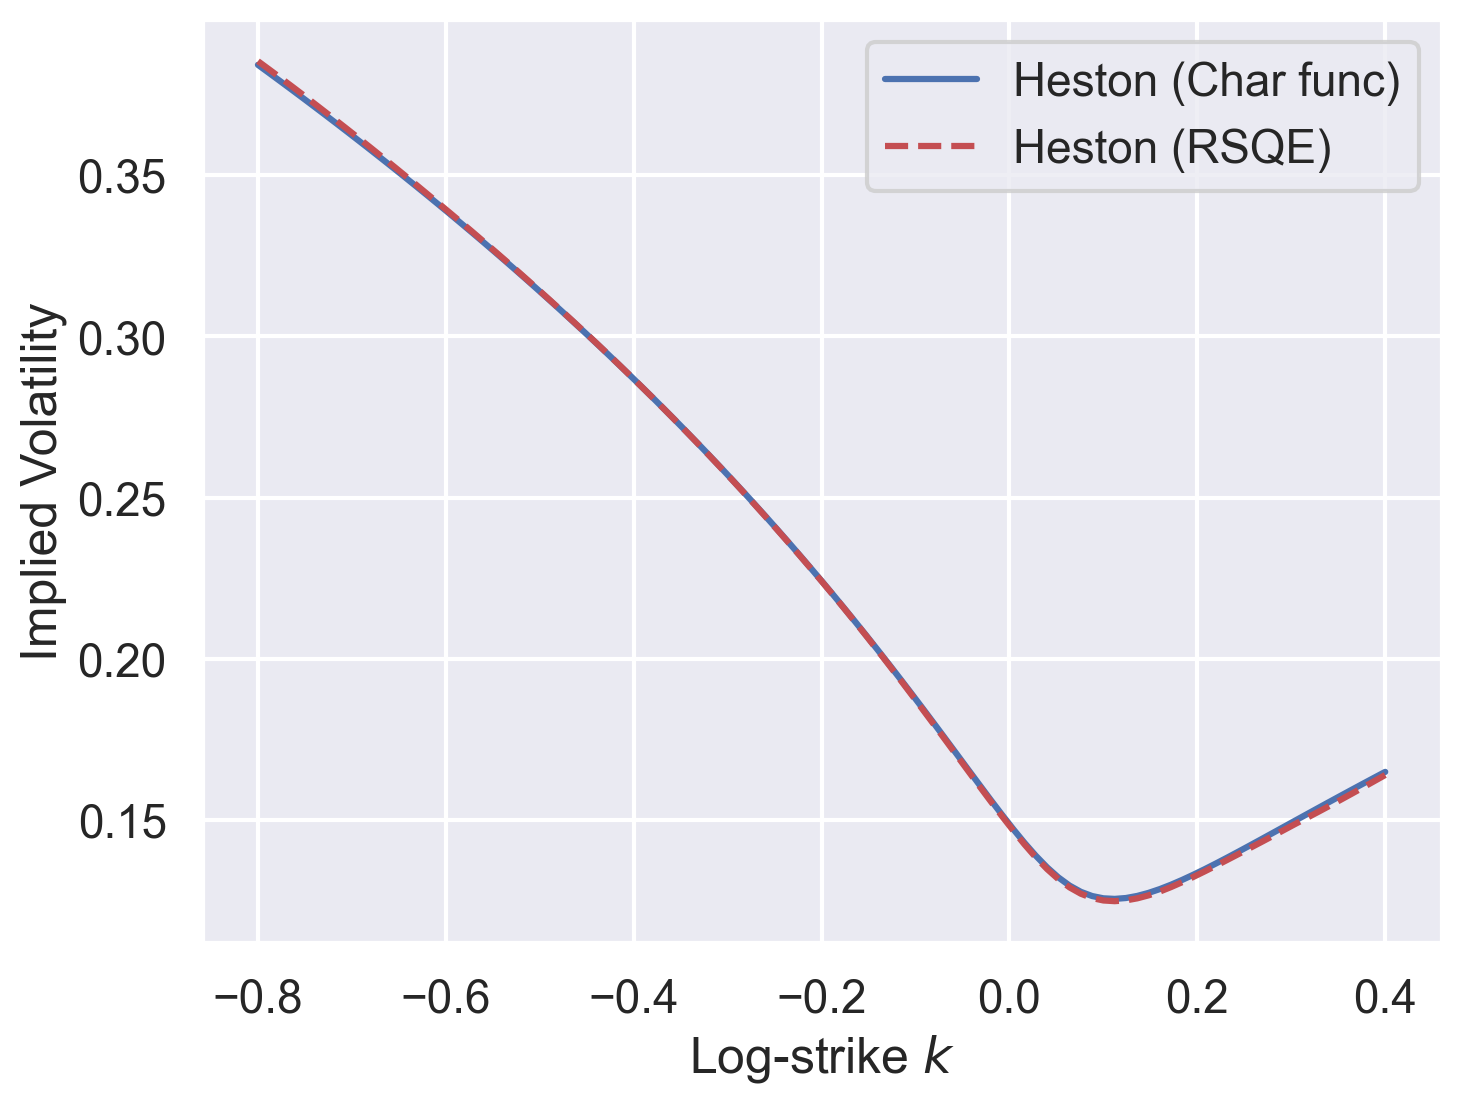

In [29]:
fig, ax = plt.subplots()
ax.plot(ks, impvol_heston, "b-", label="Heston (Char func)")
ax.plot(ks, impvol_heston_rsqe, "r--", label="Heston (RSQE)")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 10: Exact and RSQE 1-year classical Heston smiles compared.

### Plot the smile errors

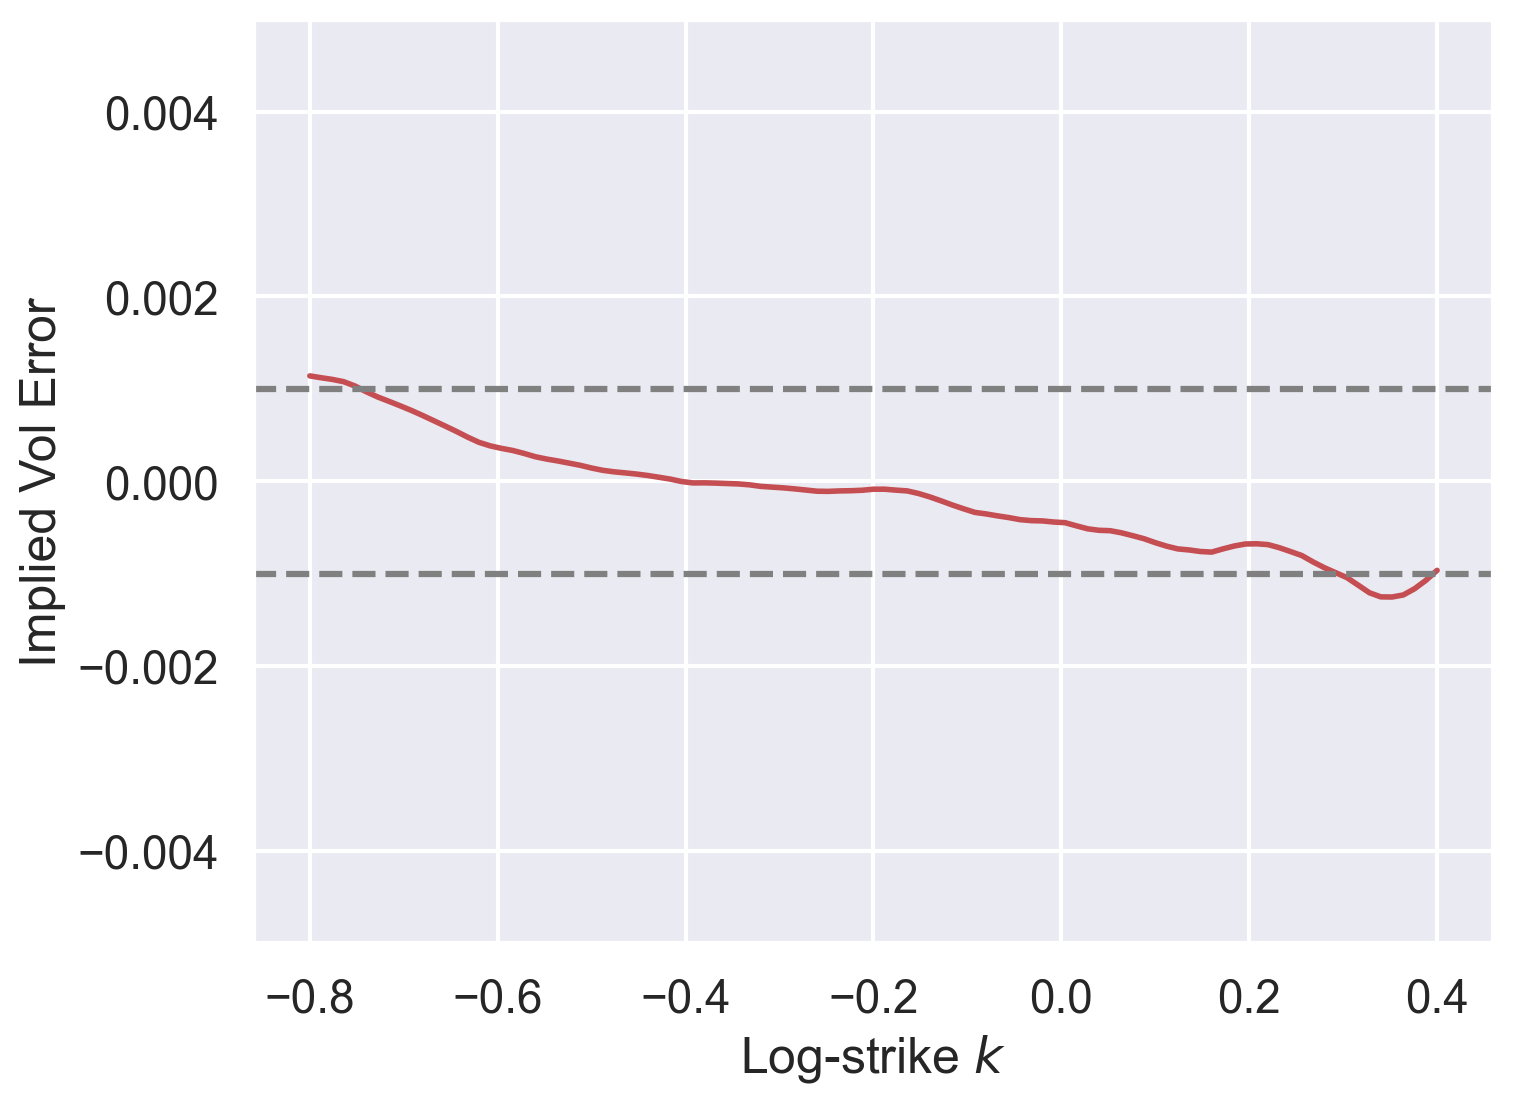

In [30]:
fig, ax = plt.subplots()
ax.plot(ks, impvol_heston_rsqe - impvol_heston, "r-", linewidth=2)
ax.axhline(y=0.001, linestyle="--", color="gray")
ax.axhline(y=-0.001, linestyle="--", color="gray")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Vol Error")
ax.set_ylim(-0.005, 0.005)
plt.show()

Figure 11: 1-year classical Heston smile errors with BCC2 parameters, using the RSQE scheme.


### A hybrid QE scheme

- The RSQE scheme matches unconditional means and variances at each step but it does not match the covariance structure of the process. 


- For example, consider the conditional covariance 
between $u_n$ and $\chi_n$ which is given by

$$
\begin{align*}
 \mathrm{cov}[u_n,\chi_n|\mathcal{F}_{n-1}] =   \int_{(n-1) \Delta }^{n \Delta}\,\kappa(n \Delta-s)\,\mathbb{E}[V_s|\mathcal{F}_{n-1}]\,ds
 \approx \bar V_n\,\mathcal{K}_0(\Delta).
 \end{align*}
$$


- The RSQE scheme sets $u_n= b_1^\star\,\chi_n $ so that

$$
\mathrm{cov}[u_n,\chi_n|\mathcal{F}_{n-1}] \approx b_1^\star\,\mathrm{var}[\chi_n|\mathcal{F}_{n-1}] = \bar{V}_n\,\sqrt{\mathcal{K}_{0,0}(\Delta)\,\Delta},
$$
which is equivalent to the approximation
    
$$
\mathcal{K}_{0}(\Delta) \approx \sqrt{\mathcal{K}_{0,0}(\Delta)\,\Delta}.
$$

- This approximation, though accurate for small $\Delta$ when the kernel $\kappa$ has no singularity at zero, 
  is obviously very inaccurate when $H$ is small.


- The essence of the hybrid scheme with $\kappa=1$ of [Bennedsen et al.]<sup id="cite_ref-Hybrid" class="reference"><a href="#cite_note-Hybrid">[2]</a></sup> is to correct the error in the approximation $
\mathcal{K}_{0}(\Delta) \approx \sqrt{\mathcal{K}_{0,0}(\Delta)\,\Delta}.
$ by simulating another random variable, uncorrelated with $u_n$, so as to match the covariance of $u_n$ and $\chi_n$.  
    - For this, we need a bivariate version of Andersen's QE scheme.


### A bivariate version of Andersen's QE scheme

- As before, let
$$
\begin{align*}
u_{n} &=  \int_{(n-1) \Delta }^{n \Delta}\,\kappa(n \Delta-s)\,\sqrt{V_s}\,dW_s,
\\
\chi_n  &= \int_{(n-1) \Delta }^{n \Delta}\,\sqrt{V_s}\,dW_s.
\end{align*}
$$


- Linear regression gives
$$
\begin{align*}
u_n &\approx \beta_{u \chi}\,\chi_n+ \varepsilon_n,
\end{align*}
$$

where $\beta_{u \chi} = \mathcal{K}_0(\Delta)/\Delta$, and $\varepsilon_n$ and $\chi_n$ are uncorrelated. 


- Since $V_n = \hat \xi_n + u_n \geq 0$, we must ensure that
$
 \beta_{u \chi}\,\chi_n + \varepsilon_n + \hat \xi_n \geq 0
$.


- We now present a bivariate QE scheme to achieve this.


### A bivariate QE scheme

- Let $\chi_n$ and $\varepsilon_n$ be generated independently using the QE scheme with the following conditional means and variances:

$$
\begin{align*}
\mathbb{E}[\beta_{u \chi}\,\chi_n|\mathcal{F}_{n-1}]&=\tfrac12 \hat \xi_{n}; \quad \mathbb{E}[\varepsilon_n|\mathcal{F}_{n-1}]=\tfrac12 \hat \xi_{n}; \\
\mathrm{var}[\chi_n|\mathcal{F}_{n-1}]&=\bar V_{n}\, \Delta;\quad  \mathrm{var}[\varepsilon_n|\mathcal{F}_{n-1}]=\bar V_{n}
\,\left(\mathcal{K}_{0,0}(\Delta)-\tfrac 1 \Delta \mathcal{K}_0(\Delta)^2\right).
\end{align*}
$$


- Then, 
$
V_n = \beta_{u \chi}\,\chi_n + \varepsilon_n + \hat \xi_n \geq 0
$. 


- Moreover, with $u_n = \beta_{u \chi}\,\chi_n+ \varepsilon_n$,

$$
\begin{align*}
\mathrm{var}[u_n|\mathcal{F}_{n-1}] &= \bar V_{n}\,\mathcal{K}_{0,0}(\Delta); \\
\mathrm{cov}[u_n,\chi_n|\mathcal{F}_{n-1}] &= \bar V_{n}\,\mathcal{K}_0(\Delta).
\end{align*}

### The hybrid QE (HQE) scheme

We summarize the resulting hybrid QE (HQE) scheme below:

1. Given $\chi_k$, for $k <n$, with $\epsilon$ very small, compute $ \hat \xi_{n} =\max\left[ \epsilon,  \xi_{n} +  \sum_{k=1}^{n-1}\,b^\star_{n-k+1}\,\chi_k \right]$.

2. Simulate $\chi_n$ and $\varepsilon_n$ using the bivariate QE scheme

3. $V_n = \hat \xi_n + \tfrac{1}{\Delta}\mathcal{K}_0(\Delta)\,\chi_n + \varepsilon_n$.

4. Finally, $X_n
=X_{n-1}-\tfrac14\,(V_n+V_{n-1})\,\Delta+\sqrt{1-\rho^2}\,\sqrt{\tilde V_{n}\,\Delta}\,Z^\perp_n
+\rho\,\chi_n$, 
where $\tilde V_n = \tfrac12(V_n+V_{n-1})$.


### Rough Heston kernel parameterizations

- The gamma kernel with $\lambda=0$ used by the HQE scheme has

$$
\kappa(\tau)= \sqrt{2 H}\,\eta\, \tau^{\alpha-1}.
$$

- On the other hand, when $\lambda=0$, the rough Heston kernel (used in the Padé approximation for example) takes the form 
$$
\kappa(\tau)=\nu\,\frac{ \tau^{\alpha-1}}{\Gamma(\alpha)},
$$


- So, $\nu$ and $\eta$ are related as
$$
\eta = \frac{\nu}{\sqrt{2 H}\, \Gamma(\alpha)}.
$$


### Rough Heston parameters

- We choose rough Heston parameters to give roughly the same 1-year smile as the classical Heston model, with $H=0.05$:

In [31]:
# Define rough Heston parameters
params_rheston = {
    "nu": 0.45,
    "eta": 0.45 / (np.sqrt(2 * 0.05) * sp.gamma(0.55)),
    "rho": -0.65,
    "H": 0.05,
    "alpha": 0.55,
    "lbd": 0.0,
}


# Define forward variance curve function
def xi_curve(s):
    return 0.04 + 0 * s

### Compute the rational approximation to the rough Heston smile

In [32]:
n_quad = 30

impvol_rheston_44 = impvol_rheston_rational(
    k=ks, tau=T, params=params_rheston, xi=xi_curve, n_pade=4, n_quad=n_quad
)
impvol_rheston_55 = impvol_rheston_rational(
    k=ks, tau=T, params=params_rheston, xi=xi_curve, n_pade=5, n_quad=n_quad
)

### Plot the classical Heston and rough Heston smiles

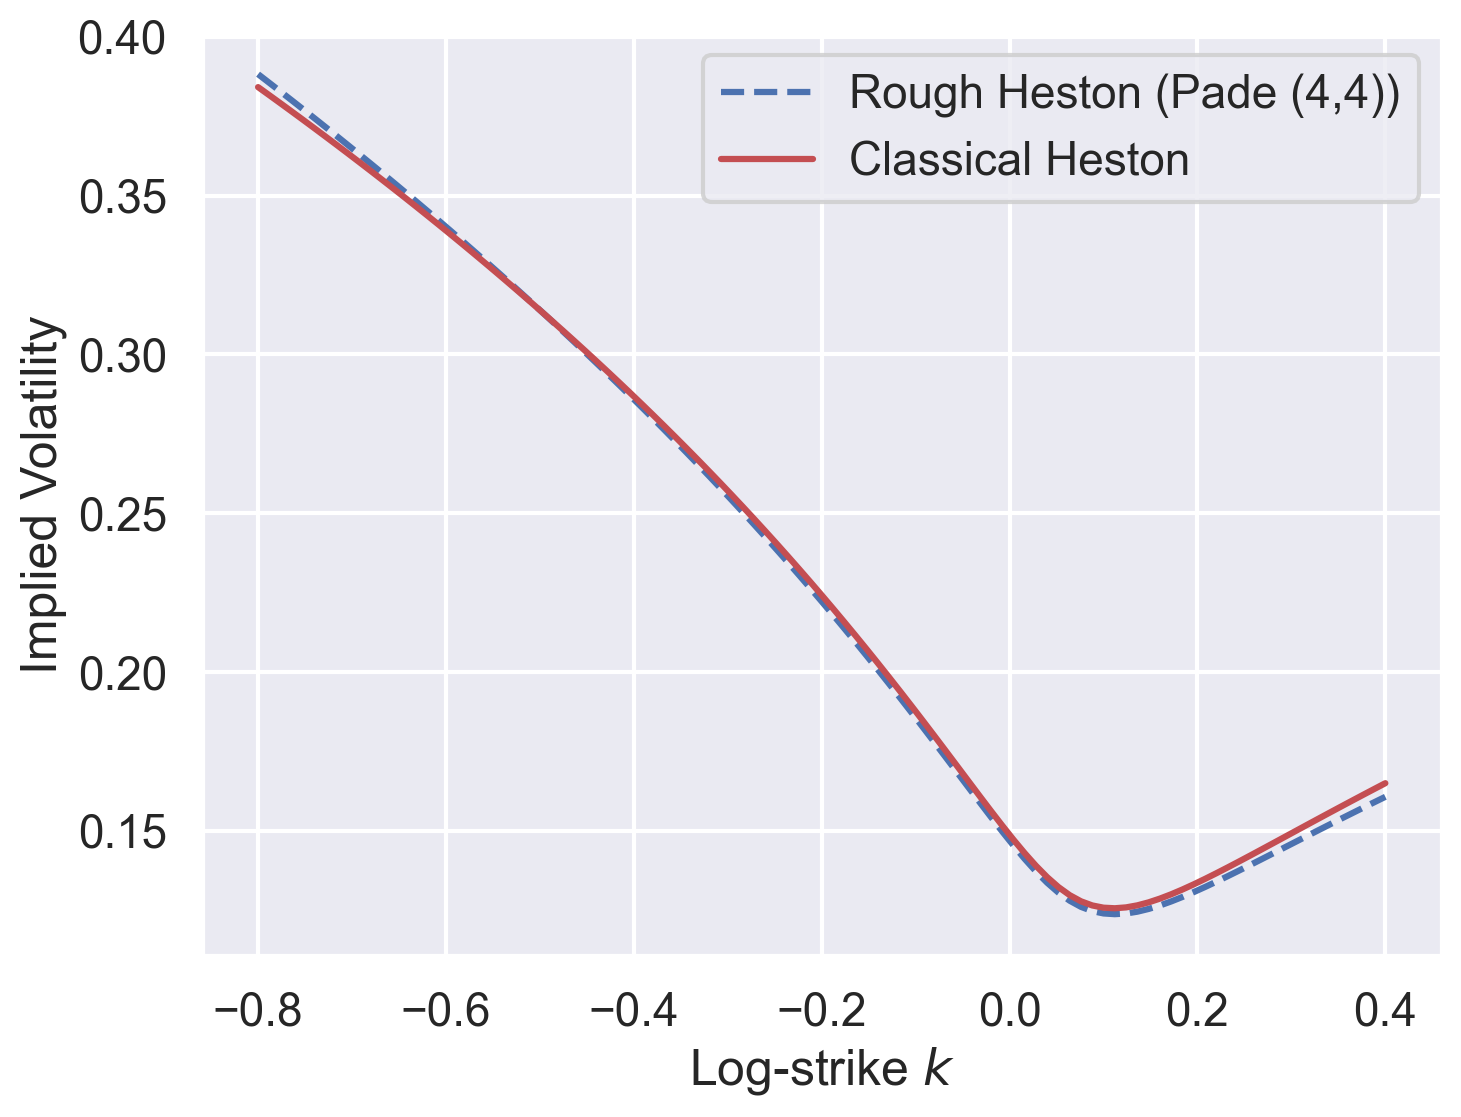

In [33]:
fig, ax = plt.subplots()
ax.plot(ks, impvol_rheston_44, "b--", label="Rough Heston (Pade (4,4))")
ax.plot(ks, impvol_heston, "r-", label="Classical Heston")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 12: Classical Heston smile with `params_heston` parameters and rough Heston smile with `params_rheston` parameters superimposed.

### The HQE code

In [34]:
res_hqe = rough_heston.simulate_hqe(
    T=T, params=params_heston, xi=xi_curve, n_mc=n_mc, n_steps=n_steps, seed=seed
)

In [35]:
impvol_heston_hqe = black_otm_impvol_mc(S=np.exp(res_hqe["x"]), k=ks, T=T)

### Plot the smile 

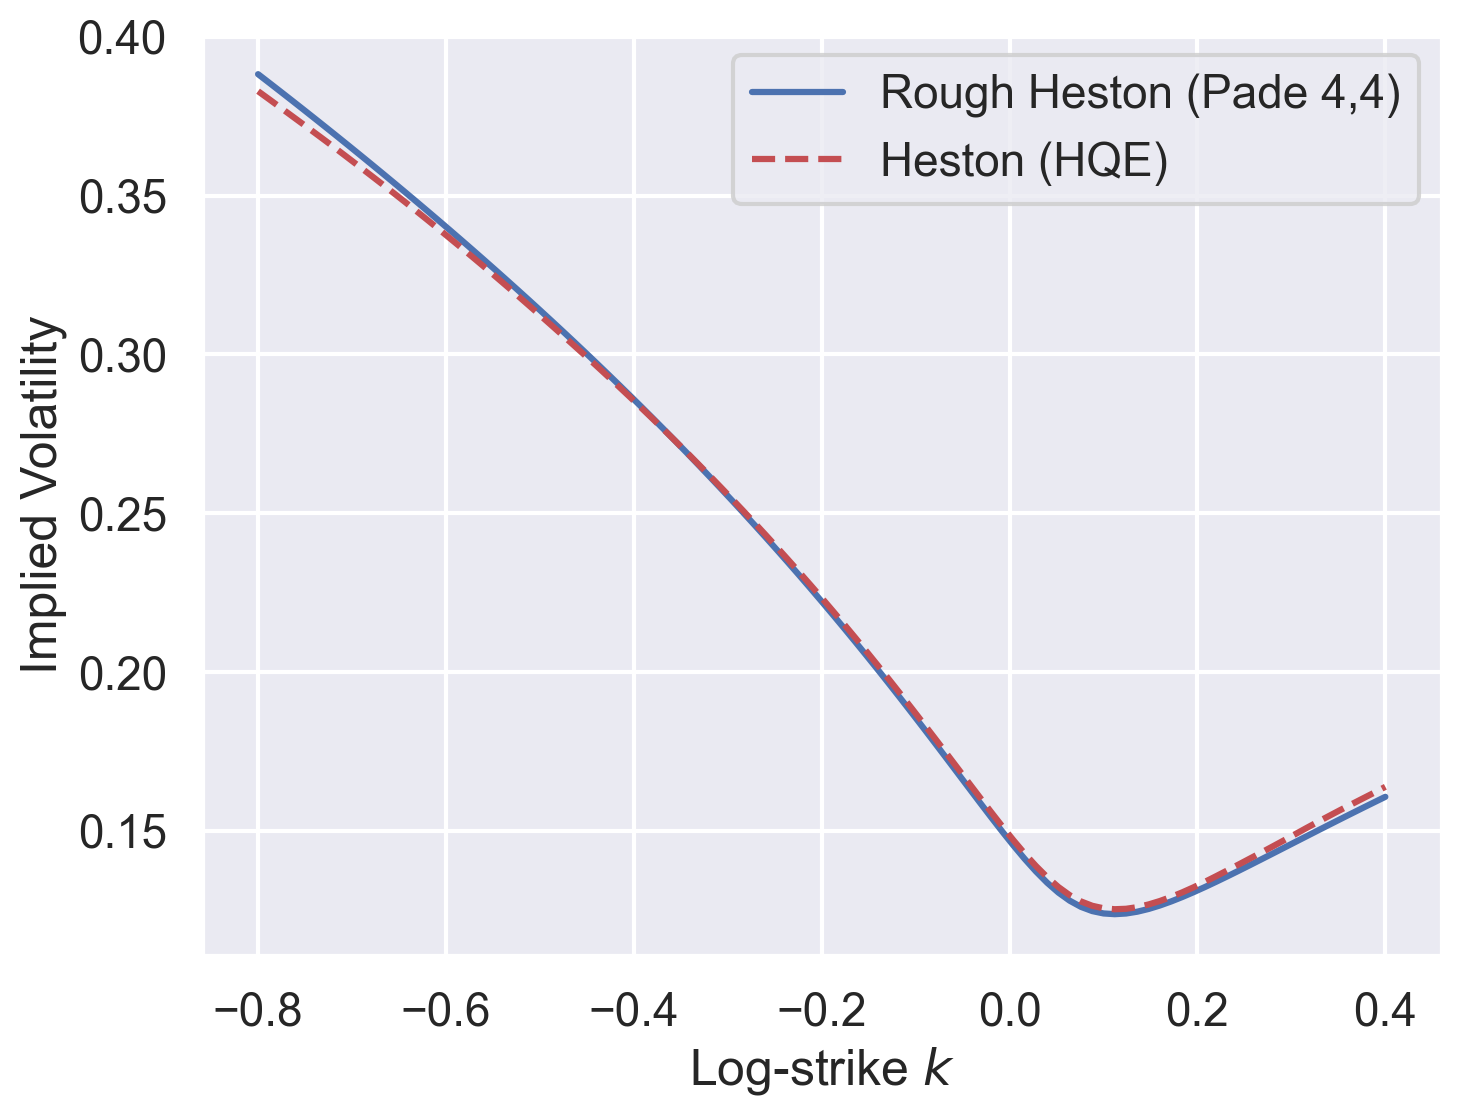

In [36]:
fig, ax = plt.subplots()
ax.plot(ks, impvol_rheston_44, "b-", label="Rough Heston (Pade 4,4)")
ax.plot(ks, impvol_heston_hqe, "r--", label="Heston (HQE)")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Volatility")
ax.legend()
plt.show()

Figure 13: The rough Heston smile with parameters `paramsHQE`.  The solid red line is from the Padé approximation; the dashed blue line is from the HQE scheme.

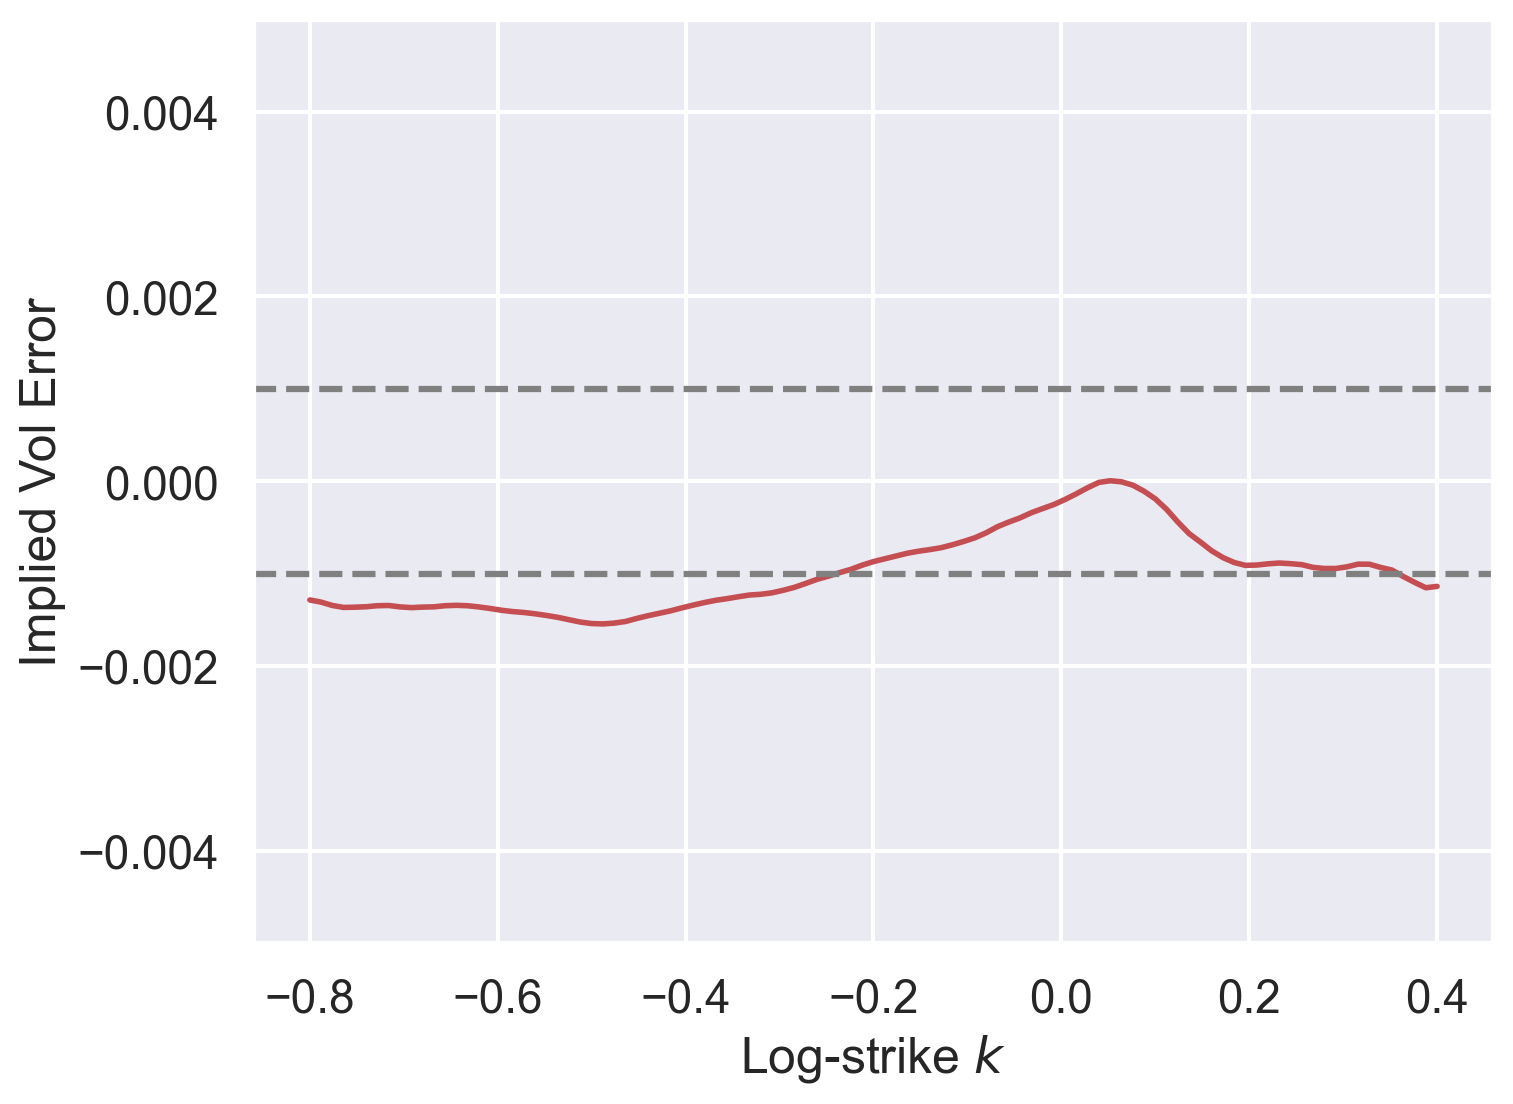

In [37]:
fig, ax = plt.subplots()
ax.plot(ks, impvol_heston_hqe - impvol_heston, "r-", linewidth=2)
ax.axhline(y=0.001, linestyle="--", color="gray")
ax.axhline(y=-0.001, linestyle="--", color="gray")
ax.set_xlabel("Log-strike $k$")
ax.set_ylabel("Implied Vol Error")
ax.set_ylim(-0.005, 0.005)
plt.show()

Figure 14: Rough Heston smile errors with `paramsHQE` parameters, using the HQE scheme.


### Convergence of the RSQE and HQE schemes

- Surprisingly (in view of Figure 9), we can also use the RQSE scheme to compute Rough Heston smiles.
    - RSQE is slower to converge.


- The following figure from [Efficient Simulation]<sup id="cite_ref-Efficient" class="reference"><a href="#cite_note-Efficient"><span>[</span>4<span>]</span></a></sup> shows that it definitely makes sense to use HQE rather than RSQE for small $H$.

<h3><img src="figures/4/rheston_rsqe_hqe_convergence.png" align = "left" width=900></h3> 

Figure 15: A 1-year rough Heston smile.  The pink reference curve is the Adams reference smile. The green-dotted and blue-dashed curves are from RSQE and HQE simulations respectively with $10^6$ paths.


### Convergence of the HQE scheme

<h3><img src="figures/4/rheston_hqe.png" align = "left" width=900></h3>

Figure 16: In the LH plot, the pink curve is the Richardson extrapolated HQE smile with 500 steps. The blue dotted lines are HQE smiles $S_n$ computed with $n \in \{25,50,100,200,500,1000\}$.  In the RH plot, we plot absolute implied volatility errors. The dashed black line with slope $-1$ is plotted for reference, clearly demonstrating order one weak convergence.  All simulations are with $10^6$ paths.

### Richardson extrapolation

- It seems that the order of weak convergence of the HQE scheme is one.  


- It therefore makes sense to use Richardson extrapolation to increase the order of convergence.




### Convergence of Richardson extrapolated HQE smiles

<h3><img src="figures/4/rheston_richardson.png" align = "left" width=900></h3>

Figure 17: In the LH plot, the pink curve is the 500-step Richardson extrapolated HQE smile. The blue dotted lines are the Richardson-extrapolated smiles $S^R_n$ computed with $n \in \{25, 50,100\}$ .  In the RH plot, we plot absolute implied volatility errors vs time steps for log-strike $k=0.04$, the dashed vertical line in the LH plot, where errors are maximized.  Errors without extrapolation are superimposed for reference, as are black-dashed lines with slopes $-1$ and $-2$ respectively.  We see evidence of order 2 weak convergence of Richardson-extrapolated smiles. 


### On Markovian approximations

- Eduardo Abi Jaber and Omar El Euch originally suggested expressing rough kernels as sums of exponentials.
    - In the rough Heston case, this is equivalent to solving $N$ classical Heston models.
    - To get reasonable agreement, at least 500 terms are required - very slow!
    
    
 - More recently, [Bayer and Breneis]<sup id="cite_ref-BB" class="reference"><a href="#cite_note-BB">[4]</a></sup> exhibited an efficient Markovian approximation scheme for the rough Heston model which is apparently competitive with HQE.
   

### Summary of Lecture 4

* We showed how to construct rational approximations of the solution of the rough Heston fractional ODE.
    - These are very fast to compute and thus good for model calibration.
    
- We presented the hybrid quadratic exponential (HQE) scheme for simulating the rough Heston model.
    - The smiles match!



- However, though rough Heaton is highly tractable, its dynamics are unreasonable.
    - And the parameters we found for February 15, 2023 look weird.



## References

<br>

<div class="reflist" style="list-style-type: decimal;">

<ol>
    

  
<li id="cite_note-Andersen"><span class="mw-cite-backlink"><b><a href="#cite_ref-Andersen">^</a></b></span>   Leif B G Andersen, Simple and efficient simulation of the Heston stochastic volatility model, <i>Journal of Computational Finance</i> <b>11</b>(3), 1–42 (2008).</li>
    
    
<li id="cite_note-Hybrid"><span class="mw-cite-backlink"><b><a href="#cite_ref-Hybrid">^</a></b></span>  Mikkel Bennedsen, Asger Lunde, and Mikko S. Pakkanen, Hybrid Scheme for Brownian Semistationary Processes, <i>Finance and Stochastics</i> <b>21</b>(4), 931–965(2017).</li>
    
    
<li id="cite_note-BBRR"><span class="mw-cite-backlink"><b><a href="#cite_ref-BBRR">^</a></b></span>   Fabio Baschetti, Giacomo Bormetti, Silvia Romagnoli and Pietro Rossi, The SINC way: A fast and accurate approach to Fourier pricing, <i>Quantitative Finance</i> <b>22</b>(3), 427-446 (2022).</li>
    
    
<li id="cite_note-BB"><span class="mw-cite-backlink"><b><a href="#cite_ref-BB">^</a></b></span>   Christian Bayer and Simon Breneis, Efficient option pricing in the rough Heston model using weak simulation schemes, <i>Quantitative Finance</i> <b>24</b>(9), 1247-1261 (2024).</li>
    
    
<li id="cite_note-Efficient"><span class="mw-cite-backlink"><b><a href="#cite_ref-Efficient">^</a></b></span>  Jim Gatheral, Efficient Simulation of Affine Forward Variance Models, <i>Risk.net</i>, <i>SSRN</i> 3876680, February (2022).</li> 
    
                  
                  
<li id="cite_note-GR"><span class="mw-cite-backlink"><b><a href="#cite_ref-GR">^</a></b></span> Jim Gatheral and Radoš Radoičić, Rational approximation of the rough Heston solution,  <i>International Journal of Theoretical and Applied Finance</i> <b>22</b>(3) 1950010 (2019).</li>
    
<li id="cite_note-GR2"><span class="mw-cite-backlink"><b><a href="#cite_ref-GR2">^</a></b></span> Jim Gatheral and Radoš Radoičić, A generalization of the rational rough Heston approximation,  <i>Quantitative Finance</i> <b>24</b>(2) 329-335 (2024).</li>
    
<li id="cite_note-Donsker"><span class="mw-cite-backlink"><b><a href="#cite_ref-Donsker">^</a></b></span>  Blanka Horvath, Antoine Jack Jacquier, and Aitor Muguruza, Functional Central Limit Theorems for Rough Volatility, <i>Finance and Stochastics</i> <b>28</b>(3), 615–661 (2024).</li>
                  
<li id="cite_note-Lewis"><span class="mw-cite-backlink"><b><a href="#cite_ref-Lewis">^</a></b></span>   Alan L. Lewis,   <i>Option Valuation under Stochastic Volatility with Mathematica Code</i>  , Finance Press: Newport Beach, CA (2000).</li>
    
    
    
</ol>
</div>